In [1]:
from __future__ import annotations

import builtins
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal, Sequence
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import itertools

from scipy.optimize import minimize


RuleName = Literal["pattern", "position"]
FitMode = Literal["shared", "per_switch"]
InitialStateMode = Literal["carry", "optimal"]
LocalAlphaMode = Literal["one", "two"]
LocalValueMode = Literal["probability", "q"]
GlobalValueMode = Literal["belief", "rule_q"]
PlotMode = Literal["replay", "simulation"]
ParallelBackend = Literal["threads", "processes"]


@dataclass(frozen=True)
class BehaviorModelConfig:
    """
    Flexible behavior model configuration.
    """

    # Model structure.
    fit_mode: FitMode = "shared"
    per_switch_initial_state: InitialStateMode = "carry"

    # Epsilon / p_base.
    fit_p_base: bool = True
    fixed_p_base: float = 0.0
    p_base_bounds: tuple[float, float] = (1e-5, 0.30)

    # Committed target lick probability.
    p_high: float = 0.999

    # Local model.
    # probability:
    #     the latent value is directly a lick probability.
    # q:
    #     the latent value is a Q-like value in [0, 1], then converted to
    #     lick probability through a sigmoid policy.
    local_value_mode: LocalValueMode = "probability"
    local_alpha_mode: LocalAlphaMode = "two"

    fit_local_beta: bool = True
    fixed_local_beta: float = 10.0
    local_beta_bounds: tuple[float, float] = (0.1, 30.0)
    local_q_center: float = 0.5

    # Local p_explore
    local_use_p_explore: bool = False
    fit_p_explore: bool = False
    fixed_p_explore: float = 0.02
    p_explore_bounds: tuple[float, float] = (1e-5, 0.30)

    # Shared learning-rate bounds.
    alpha_bounds: tuple[float, float] = (1e-6, 1.0)

    # Global model.
    # belief:
    #     directly maintain b = P(pattern).
    # rule_q:
    #     maintain Q_pattern and Q_position, then use softmax beta to obtain
    #     P(pattern) before mapping rule probability to lick probability.
    global_value_mode: GlobalValueMode = "belief"
    global_alpha_mode: LocalAlphaMode = "two"   # "one" or "two"

    fit_global_beta: bool = True
    fixed_global_beta: float = 10.0
    global_beta_bounds: tuple[float, float] = (0.1, 30.0)
    global_use_threshold: bool = False
    global_remove_miss_state: bool = False

    # Threshold is now grid-searched, not continuously optimized.
    theta_grid: tuple[float, ...] = (0.55, 0.60, 0.70, 0.80, 0.90, 0.95)
    max_theta_grid_combinations: int = 5000

    # Objective.
    fit_objective: str = "all"      # all / diagnostic / weighted
    diagnostic_weight: float = 5.0
    
    # Position filtering.
    # If True, positions listed in task_irrelevant_position_numbers are removed
    # from fitting, replay, simulation, and mouse performance computation.
    exclude_task_irrelevant_positions: bool = False

    # 1-based position numbers. Positions 2 and 4 correspond to step_index 1 and 3.
    task_irrelevant_position_numbers: tuple[int, ...] = (2, 4)

    # Safety check: excluded positions should not contain pattern/position targets.
    require_excluded_positions_non_target: bool = True

    # Optimization.
    n_starts: int = 10
    optimizer_maxiter: int = 400
    optimizer_ftol: float = 1e-8
    random_seed: int = 0

    # Parallel.
    n_jobs: int = 1
    parallel_backend: ParallelBackend = "threads"
    parallelize_restarts: bool = False

    # Folder search.
    recursive_search: bool = True

    mouse_id_filter: tuple[str, ...] = ()
    filter_mouse_id_in_path: bool = True
    
    # Plotting / simulation.
    pre_switch_display_trials: int = 10
    performance_window: int = 20
    plot_mode: PlotMode = "simulation"
    n_sim: int = 500


def _mat_get(obj: Any, field: str) -> Any:
    """
    Get a field from a MATLAB struct loaded by scipy.io.loadmat.
    Robust to accidental overwriting of built-in names in notebooks.
    """
    if isinstance(obj, builtins.dict):
        if field not in obj:
            raise KeyError(f"Missing field {field!r}.")
        return obj[field]

    if hasattr(obj, field):
        return getattr(obj, field)

    if isinstance(obj, np.void) and obj.dtype.names is not None:
        if field not in obj.dtype.names:
            raise KeyError(f"Missing field {field!r}.")
        return obj[field]

    raise KeyError(f"Missing field {field!r}.")


def _flatten_numeric(value: Any) -> np.ndarray:
    """
    Flatten MATLAB numeric-like values into a 1D float array.
    """
    output: builtins.list[float] = []

    def collect(x: Any) -> None:
        if x is None:
            return

        if isinstance(x, np.ndarray):
            if x.dtype == object:
                for item in x.ravel():
                    collect(item)
            else:
                try:
                    arr = x.astype(float).ravel()
                except (TypeError, ValueError):
                    return
                output.extend(arr[np.isfinite(arr)].tolist())
            return

        if isinstance(x, (builtins.list, builtins.tuple)):
            for item in x:
                collect(item)
            return

        try:
            number = float(x)
        except (TypeError, ValueError):
            return

        if np.isfinite(number):
            output.append(number)

    collect(value)
    return np.asarray(output, dtype=float)


def _to_int_array(value: Any, *, expected_size: int = 5) -> np.ndarray:
    arr = _flatten_numeric(value).astype(int)

    if arr.size != expected_size:
        raise ValueError(
            f"Expected {expected_size} values, got {arr.size}: {arr}"
        )

    return arr


def _to_scalar_float(value: Any) -> float:
    arr = _flatten_numeric(value)

    if arr.size == 0:
        return 0.0

    if arr.size != 1:
        raise ValueError(f"Expected scalar, got {arr}.")

    return float(arr[0])


def load_laps_from_mat(file_path: str | Path) -> list[Any]:
    """
    Load the lap array from one MATLAB behavior file.
    """
    file_path = Path(file_path).expanduser().resolve()

    mat = sio.loadmat(
        file_path,
        squeeze_me=True,
        struct_as_record=False,
    )

    if "lap" not in mat:
        raise KeyError(f"No 'lap' field found in {file_path}.")

    laps = np.asarray(mat["lap"], dtype=object).ravel().tolist()

    if len(laps) == 0:
        raise ValueError(f"No trials found in {file_path}.")

    return laps


def _rule_from_trial_style(trial_style: Sequence[int]) -> RuleName:
    """
    Infer task rule from the first digit of trial_style.

    First digit:
        1 = pattern
        2 = position
    """
    style = np.asarray(trial_style, dtype=int).ravel()

    if style.size != 5:
        raise ValueError(f"trial_style must have 5 values, got {style}.")

    rule_digits = style // 10
    unique_digits = np.unique(rule_digits)

    if unique_digits.size != 1:
        raise ValueError(
            "Inconsistent rule digits within one trial_style: "
            f"trial_style={style}, rule_digits={rule_digits}"
        )

    rule_digit = int(unique_digits[0])

    if rule_digit == 1:
        return "pattern"

    if rule_digit == 2:
        return "position"

    raise ValueError(
        f"Invalid rule digit {rule_digit}. Expected 1 or 2. "
        f"trial_style={style}"
    )


def _decode_trial_style(trial_style: Sequence[int]) -> tuple[str, ...]:
    """
    Decode trial_style into five position-wise cue identities.

    Second digit:
        0 = blank
        1 = A
        2 = B
        3 = C
    """
    code_to_cue = {
        0: "blank",
        1: "A",
        2: "B",
        3: "C",
    }

    cues = []

    for raw_code in np.asarray(trial_style, dtype=int).ravel():
        cue_code = int(raw_code) % 10

        if cue_code not in code_to_cue:
            raise ValueError(
                f"Invalid cue code {cue_code} in trial_style={trial_style}."
            )

        cues.append(code_to_cue[cue_code])

    if cues.count("A") != 1:
        raise ValueError(f"Expected one A cue, got {cues}.")

    if cues.count("B") != 1:
        raise ValueError(f"Expected one B cue, got {cues}.")

    if cues.count("C") != 1:
        raise ValueError(f"Expected one C cue, got {cues}.")

    if cues.count("blank") != 2:
        raise ValueError(f"Expected two blank cues, got {cues}.")

    return tuple(cues)


def _trial_code_from_cues(cues: Sequence[str]) -> str:
    """
    Convert five-position cue sequence into CAB / ACB / ABC style code.
    """
    return "".join(cue for cue in cues if cue != "blank")


def _actions_from_lap(lap: Any, cues: Sequence[str]) -> np.ndarray:
    """
    Convert cue-specific lick numbers into five position-wise actions.

    A lick number > 0 is coded as action = 1.
    """
    lick_by_cue = {
        "A": int(_to_scalar_float(_mat_get(lap, "A_lick_number")) > 0),
        "B": int(_to_scalar_float(_mat_get(lap, "B_lick_number")) > 0),
        "C": int(_to_scalar_float(_mat_get(lap, "C_lick_number")) > 0),
        "blank_one": int(
            _to_scalar_float(_mat_get(lap, "blank_one_lick_number")) > 0
        ),
        "blank_two": int(
            _to_scalar_float(_mat_get(lap, "blank_two_lick_number")) > 0
        ),
    }

    actions = np.zeros(5, dtype=int)
    blank_counter = 0

    for step_index, cue in enumerate(cues):
        if cue in {"A", "B", "C"}:
            actions[step_index] = lick_by_cue[cue]

        elif cue == "blank":
            blank_counter += 1

            if blank_counter == 1:
                actions[step_index] = lick_by_cue["blank_one"]
            elif blank_counter == 2:
                actions[step_index] = lick_by_cue["blank_two"]
            else:
                raise ValueError("More than two blank positions were found.")

        else:
            raise ValueError(f"Unknown cue identity: {cue!r}.")

    return actions


def build_trials_from_mat(file_path: str | Path) -> list[dict]:
    """
    Convert one MATLAB file into an ordered trial list.
    """
    laps = load_laps_from_mat(file_path)
    trials = []

    for trial_id, lap in enumerate(laps):
        trial_style = _to_int_array(
            _mat_get(lap, "trial_style"),
            expected_size=5,
        )

        task_rule = _rule_from_trial_style(trial_style)
        cues = _decode_trial_style(trial_style)
        trial_code = _trial_code_from_cues(cues)
        actions = _actions_from_lap(lap, cues)

        trials.append(
            {
                "trial_id": int(trial_id),
                "task_rule": task_rule,
                "trial_style": trial_style,
                "trial_code": trial_code,
                "cues": cues,
                "actions": actions,
            }
        )

    return trials


def build_decision_table_from_trials(
    trials: Sequence[dict],
) -> pd.DataFrame:
    """
    Expand each trial into five sequential binary decisions.
    """
    rows = []
    trial_rules = []

    for trial in trials:
        trial_id = int(trial["trial_id"])
        task_rule: RuleName = trial["task_rule"]
        cues = tuple(trial["cues"])
        actions = np.asarray(trial["actions"], dtype=int)

        if actions.size != 5:
            raise ValueError(
                f"Trial {trial_id}: expected 5 actions, got {actions.size}."
            )

        c_position = int(cues.index("C"))
        pattern_target_index = c_position
        position_target_index = 2

        trial_rules.append(task_rule)

        for step_index in range(5):
            pattern_target = int(step_index == pattern_target_index)
            position_target = int(step_index == position_target_index)

            if task_rule == "pattern":
                true_target = pattern_target
            elif task_rule == "position":
                true_target = position_target
            else:
                raise ValueError(f"Unknown task rule: {task_rule!r}.")

            action = int(actions[step_index])
            reward = int(action == 1 and true_target == 1)

            rows.append(
                {
                    "trial_id": trial_id,
                    "task_rule": task_rule,
                    "trial_code": trial["trial_code"],
                    "step_index": int(step_index),
                    "position_number": int(step_index + 1),
                    "cue_identity": cues[step_index],
                    "state_key": (int(step_index), cues[step_index]),

                    "action": action,
                    "reward": reward,

                    "pattern_target": int(pattern_target),
                    "position_target": int(position_target),
                    "true_target": int(true_target),

                    "pattern_target_index": int(pattern_target_index),
                    "position_target_index": int(position_target_index),
                    "is_diagnostic": bool(pattern_target != position_target),
                    "is_diagnostic_trial": bool(
                        pattern_target_index != position_target_index
                    ),
                }
            )

    decision_df = pd.DataFrame(rows)

    if decision_df.empty:
        raise ValueError("No decisions were generated.")

    switch_records = []
    rule_block_ids = np.zeros(len(trial_rules), dtype=int)
    current_block_id = 0

    for trial_id in range(1, len(trial_rules)):
        old_rule = trial_rules[trial_id - 1]
        new_rule = trial_rules[trial_id]

        if new_rule != old_rule:
            current_block_id += 1

            switch_records.append(
                {
                    "switch_number": int(current_block_id),
                    "rule_block_id": int(current_block_id),
                    "switch_trial_id": int(trial_id),
                    "old_rule": old_rule,
                    "new_rule": new_rule,
                    "switch_direction": f"{old_rule}_to_{new_rule}",
                }
            )

        rule_block_ids[trial_id] = current_block_id

    if not switch_records:
        raise ValueError("No pattern-position switch was found.")

    unique_states = list(builtins.dict.fromkeys(decision_df["state_key"]))

    state_to_id = {
        state: state_id
        for state_id, state in enumerate(unique_states)
    }

    decision_df["state_id"] = (
        decision_df["state_key"]
        .map(state_to_id)
        .astype(int)
    )

    trial_to_block = {
        trial_id: int(block_id)
        for trial_id, block_id in enumerate(rule_block_ids)
    }

    decision_df["rule_block_id"] = (
        decision_df["trial_id"]
        .map(trial_to_block)
        .astype(int)
    )

    first_switch_trial_id = int(switch_records[0]["switch_trial_id"])

    decision_df["first_switch_trial_id"] = first_switch_trial_id
    decision_df["is_post_switch"] = (
        decision_df["trial_id"] >= first_switch_trial_id
    )

    block_direction = {0: "initial"}

    for record in switch_records:
        block_direction[int(record["rule_block_id"])] = record["switch_direction"]

    decision_df["block_direction"] = (
        decision_df["rule_block_id"].map(block_direction)
    )

    decision_df["initial_rule"] = trial_rules[0]
    decision_df["n_switches"] = len(switch_records)

    decision_df.attrs["initial_rule"] = trial_rules[0]
    decision_df.attrs["first_switch_trial_id"] = first_switch_trial_id
    decision_df.attrs["switches"] = switch_records
    decision_df.attrs["state_to_id"] = state_to_id

    return decision_df


def _global_feedback_alpha(
    *,
    reward: int,
    alpha_up: float,
    alpha_down: float,
) -> float:
    """
    Select global learning rate by feedback valence.

    alpha_up:
        learning rate for rewarded feedback.

    alpha_down:
        learning rate for unrewarded feedback.

    Direction is handled separately by the supported rule.
    """
    if int(reward) == 1:
        return float(alpha_up)

    return float(alpha_down)


def build_decision_table_from_mat(
    file_path: str | Path,
) -> pd.DataFrame:
    trials = build_trials_from_mat(file_path)
    return build_decision_table_from_trials(trials)

In [2]:
def _mean_param_map(
    param_map: dict[int, float],
    *,
    default: float = 0.0,
) -> float:
    """
    Mean value across switch blocks.

    Used only for pre-switch display when fit_mode='per_switch'.
    """
    if param_map is None or len(param_map) == 0:
        return float(default)

    values = np.asarray(list(param_map.values()), dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return float(default)

    return float(values.mean())


def _old_rule_display_prob(
    old_rule: RuleName,
    *,
    pattern_target: int,
    position_target: int,
    p_base_display: float,
    p_high: float,
) -> float:
    """
    Pre-switch display policy.

    Pre-switch data are not used for fitting, but replay/simulation plots
    should still include p_base for non-target licks.
    """
    return _expert_policy_prob(
        old_rule,
        pattern_target=pattern_target,
        position_target=position_target,
        p_base=p_base_display,
        p_high=p_high,
    )


def _post_switch_df(decision_df: pd.DataFrame) -> pd.DataFrame:
    first_switch_trial_id = int(
        decision_df["first_switch_trial_id"].iloc[0]
    )

    post_df = (
        decision_df[
            decision_df["trial_id"] >= first_switch_trial_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    if post_df.empty:
        raise ValueError("No post-switch decisions were found.")

    return post_df


def _display_decision_df(
    decision_df: pd.DataFrame,
    *,
    pre_switch_trials: int,
) -> pd.DataFrame:
    first_switch_trial_id = int(
        decision_df["first_switch_trial_id"].iloc[0]
    )

    start_trial = max(0, first_switch_trial_id - pre_switch_trials)

    return (
        decision_df[
            decision_df["trial_id"] >= start_trial
        ]
        .copy()
        .reset_index(drop=True)
    )
    
    
def _apply_task_position_filter(
    decision_df: pd.DataFrame,
    config: BehaviorModelConfig,
) -> pd.DataFrame:
    """
    Optionally remove task-irrelevant positions from model fitting,
    replay, simulation, and behavior scoring.

    By default, positions are 1-based:
        position 2 -> step_index 1
        position 4 -> step_index 3

    If config.exclude_task_irrelevant_positions=False, this returns the
    original dataframe unchanged.
    """
    if not config.exclude_task_irrelevant_positions:
        return decision_df

    if decision_df.empty:
        return decision_df

    excluded_positions = tuple(
        int(x)
        for x in config.task_irrelevant_position_numbers
    )

    if len(excluded_positions) == 0:
        return decision_df

    work = decision_df.copy()

    if "position_number" in work.columns:
        position_number = work["position_number"].astype(int)
    elif "step_index" in work.columns:
        position_number = work["step_index"].astype(int) + 1
        work["position_number"] = position_number
    else:
        raise ValueError(
            "Cannot apply position filter because neither 'position_number' "
            "nor 'step_index' exists."
        )

    exclude_mask = position_number.isin(excluded_positions)

    excluded = work.loc[exclude_mask].copy()

    if (
        config.require_excluded_positions_non_target
        and not excluded.empty
        and {
            "pattern_target",
            "position_target",
            "true_target",
        }.issubset(excluded.columns)
    ):
        bad = excluded[
            (excluded["pattern_target"].astype(int) == 1)
            | (excluded["position_target"].astype(int) == 1)
            | (excluded["true_target"].astype(int) == 1)
        ]

        if not bad.empty:
            preview_cols = [
                c
                for c in [
                    "trial_id",
                    "step_index",
                    "position_number",
                    "trial_code",
                    "task_rule",
                    "pattern_target",
                    "position_target",
                    "true_target",
                ]
                if c in bad.columns
            ]

            preview = bad[preview_cols].head(10).to_dict("records")

            raise ValueError(
                "Excluded positions contain rule-target decisions. "
                "This means positions listed in "
                "config.task_irrelevant_position_numbers are not always "
                "task-irrelevant. "
                f"Preview: {preview}"
            )

    filtered = (
        work.loc[~exclude_mask]
        .copy()
        .reset_index(drop=True)
    )

    if filtered.empty:
        raise ValueError(
            "All decisions were removed by the task position filter. "
            f"task_irrelevant_position_numbers={excluded_positions}"
        )

    # Preserve attrs when filtering a decision_df.
    filtered.attrs.update(getattr(decision_df, "attrs", {}))

    return filtered


def _switch_block_ids(decision_df: pd.DataFrame) -> list[int]:
    return [
        int(record["rule_block_id"])
        for record in decision_df.attrs["switches"]
    ]


def _switch_old_rule_by_block(decision_df: pd.DataFrame) -> dict[int, RuleName]:
    return {
        int(record["rule_block_id"]): record["old_rule"]
        for record in decision_df.attrs["switches"]
    }


def _clip_prob(p: float) -> float:
    return float(np.clip(p, 1e-12, 1.0 - 1e-12))


def _expert_policy_prob(
    rule: RuleName,
    *,
    pattern_target: int,
    position_target: int,
    p_base: float,
    p_high: float,
) -> float:
    if rule == "pattern":
        target = int(pattern_target)
    elif rule == "position":
        target = int(position_target)
    else:
        raise ValueError(f"Unknown rule: {rule!r}")

    return float(p_high if target == 1 else p_base)


def _local_policy_prob(
    value: float,
    *,
    p_explore: float,
    use_p_explore: bool,
) -> float:
    """
    Convert local state value into lick probability.

    Without p_explore:
        p = V_s

    With p_explore:
        p = p_explore + (1 - p_explore) * V_s
    """
    value = float(np.clip(value, 0.0, 1.0))

    if not use_p_explore:
        return _clip_prob(value)

    p_explore = float(np.clip(p_explore, 0.0, 1.0))
    p = p_explore + (1.0 - p_explore) * value

    return _clip_prob(p)





def _sigmoid(x: float | np.ndarray) -> float | np.ndarray:
    """
    Numerically stable sigmoid.
    """
    x_arr = np.asarray(x, dtype=float)
    out = np.empty_like(x_arr, dtype=float)

    pos = x_arr >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-x_arr[pos]))

    exp_x = np.exp(x_arr[~pos])
    out[~pos] = exp_x / (1.0 + exp_x)

    if np.ndim(x) == 0:
        return float(out)

    return out


def _q_policy_prob(
    q_value: float,
    *,
    p_base: float,
    p_high: float,
    beta: float,
    center: float = 0.5,
) -> float:
    """
    Convert a Q-like latent value in [0, 1] to lick probability.

    Q is not itself the probability. The sigmoid controls how sharply
    value is expressed as licking.
    """
    q = float(np.clip(q_value, 0.0, 1.0))
    beta = float(max(beta, 0.0))
    p_base = float(np.clip(p_base, 0.0, 1.0))
    p_high = float(np.clip(p_high, p_base, 1.0))

    drive = float(_sigmoid(beta * (q - float(center))))
    p = p_base + drive * (p_high - p_base)

    return _clip_prob(p)


def _local_model_policy_prob(
    latent_value: float,
    *,
    p_base: float,
    p_high: float,
    p_explore: float,
    beta: float,
    config: BehaviorModelConfig,
) -> float:
    """
    Convert the local latent variable into a lick probability.

    probability mode:
        latent_value is directly the lick-probability-like value.

    q mode:
        latent_value is a Q-like value and is passed through a sigmoid policy.
    """
    if config.local_value_mode == "probability":
        return _local_policy_prob(
            latent_value,
            p_explore=p_explore,
            use_p_explore=config.local_use_p_explore,
        )

    if config.local_value_mode == "q":
        p = _q_policy_prob(
            latent_value,
            p_base=p_base,
            p_high=p_high,
            beta=beta,
            center=config.local_q_center,
        )

        if config.local_use_p_explore:
            p_explore = float(np.clip(p_explore, 0.0, 1.0))
            p = p_explore + (1.0 - p_explore) * p

        return _clip_prob(p)

    raise ValueError("local_value_mode must be 'probability' or 'q'.")


def _initialize_local_latent_values(
    decision_df: pd.DataFrame,
    *,
    old_rule: RuleName,
    p_base: float,
    p_high: float,
    config: BehaviorModelConfig,
) -> np.ndarray:
    """
    Initialize local latent values according to the old rule.

    probability mode:
        target states start at p_high and non-target states at p_base.

    q mode:
        target states start at Q=1 and non-target states at Q=0.
        p_base/p_high are then handled by the policy layer.
    """
    if config.local_value_mode == "probability":
        return _initialize_local_values(
            decision_df,
            old_rule=old_rule,
            p_base=p_base,
            p_high=p_high,
        )

    if config.local_value_mode == "q":
        return _initialize_local_values(
            decision_df,
            old_rule=old_rule,
            p_base=0.0,
            p_high=1.0,
        )

    raise ValueError("local_value_mode must be 'probability' or 'q'.")


def _softmax_pattern_probability(
    q_pattern: float,
    q_position: float,
    *,
    beta: float,
) -> float:
    """
    Softmax over two rule values. Returns P(pattern).
    """
    beta = float(max(beta, 0.0))
    logits = beta * np.asarray([q_pattern, q_position], dtype=float)
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    probs = probs / probs.sum()

    return float(probs[0])


def _initialize_rule_q(old_rule: RuleName) -> np.ndarray:
    """
    Initialize rule-level Q values from the old rule.
    """
    if old_rule == "pattern":
        return np.asarray([1.0, 0.0], dtype=float)

    if old_rule == "position":
        return np.asarray([0.0, 1.0], dtype=float)

    raise ValueError(f"Unknown rule: {old_rule!r}")


def _feedback_rule(
    *,
    pattern_target: int,
    position_target: int,
    action: int,
    reward: int,
) -> RuleName | None:
    """
    Return the rule supported by this feedback.

    This is used by global models only.

    Logic
    -----
    Only diagnostic licks provide rule evidence.

    If the animal licks a pattern-only target:
        reward     -> supports pattern
        no reward  -> supports position

    If the animal licks a position-only target:
        reward     -> supports position
        no reward  -> supports pattern

    No-lick does not update the rule belief/value.
    Non-diagnostic positions do not update the rule belief/value.
    """
    pattern_target = int(pattern_target)
    position_target = int(position_target)
    action = int(action)
    reward = int(reward)

    if action == 0:
        return None

    if pattern_target == position_target:
        return None

    if pattern_target == 1 and position_target == 0:
        if reward == 1:
            return "pattern"
        return "position"

    if pattern_target == 0 and position_target == 1:
        if reward == 1:
            return "position"
        return "pattern"

    return None


def _initialize_belief(old_rule: RuleName) -> float:
    if old_rule == "pattern":
        return 1.0

    if old_rule == "position":
        return 0.0

    raise ValueError(f"Unknown rule: {old_rule!r}")


def _initialize_local_values(
    decision_df: pd.DataFrame,
    *,
    old_rule: RuleName,
    p_base: float,
    p_high: float,
) -> np.ndarray:
    n_states = int(decision_df["state_id"].max()) + 1
    values = np.empty(n_states, dtype=float)

    state_table = (
        decision_df[
            [
                "state_id",
                "pattern_target",
                "position_target",
            ]
        ]
        .drop_duplicates("state_id")
        .sort_values("state_id")
    )

    for row in state_table.itertuples(index=False):
        values[int(row.state_id)] = _expert_policy_prob(
            old_rule,
            pattern_target=int(row.pattern_target),
            position_target=int(row.position_target),
            p_base=p_base,
            p_high=p_high,
        )

    return values


def _global_rule_drives(
    *,
    belief_pattern: float,
    use_threshold: bool,
    theta: float | None,
    remove_miss_state: bool,
) -> tuple[float, float, str, dict]:
    """
    Return effective pattern-drive and position-drive.

    remove_miss_state=False:
        original belief mixture:
            pattern only / position only

    remove_miss_state=True:
        mixture categories:
            pattern only / position only / both
        with neither removed.
    """
    b = float(np.clip(belief_pattern, 0.0, 1.0))

    if use_threshold:
        if theta is None:
            raise ValueError("theta is required when use_threshold=True.")

        if b >= theta:
            weights = {
                "pattern_only": 1.0,
                "position_only": 0.0,
                "both": 0.0,
                "neither": 0.0,
            }
            return 1.0, 0.0, "pattern_commit", weights

        if b <= 1.0 - theta:
            weights = {
                "pattern_only": 0.0,
                "position_only": 1.0,
                "both": 0.0,
                "neither": 0.0,
            }
            return 0.0, 1.0, "position_commit", weights

    qP_raw = b
    qZ_raw = 1.0 - b

    if not remove_miss_state:
        weights = {
            "pattern_only": qP_raw,
            "position_only": qZ_raw,
            "both": 0.0,
            "neither": 0.0,
        }

        return qP_raw, qZ_raw, "continuous_mix", weights

    pattern_only = qP_raw * (1.0 - qZ_raw)
    position_only = (1.0 - qP_raw) * qZ_raw
    both = qP_raw * qZ_raw
    neither = (1.0 - qP_raw) * (1.0 - qZ_raw)

    denom = pattern_only + position_only + both

    if denom <= 0:
        weights = {
            "pattern_only": 0.5,
            "position_only": 0.5,
            "both": 0.0,
            "neither": 0.0,
        }
    else:
        weights = {
            "pattern_only": pattern_only / denom,
            "position_only": position_only / denom,
            "both": both / denom,
            "neither": 0.0,
        }

    qP_eff = weights["pattern_only"] + weights["both"]
    qZ_eff = weights["position_only"] + weights["both"]

    return float(qP_eff), float(qZ_eff), "continuous_mix_no_miss", weights


def _global_policy_prob(
    *,
    belief_pattern: float,
    pattern_target: int,
    position_target: int,
    p_base: float,
    p_high: float,
    use_threshold: bool,
    theta: float | None,
    remove_miss_state: bool,
) -> tuple[float, str, float, float, dict]:
    """
    Global policy probability for one decision.
    """
    qP, qZ, policy_mode, weights = _global_rule_drives(
        belief_pattern=belief_pattern,
        use_threshold=use_threshold,
        theta=theta,
        remove_miss_state=remove_miss_state,
    )

    if pattern_target == 1 and position_target == 1:
        return float(p_high), policy_mode, qP, qZ, weights

    if pattern_target == 1:
        p = p_base + qP * (p_high - p_base)
        return float(p), policy_mode, qP, qZ, weights

    if position_target == 1:
        p = p_base + qZ * (p_high - p_base)
        return float(p), policy_mode, qP, qZ, weights

    return float(p_base), policy_mode, qP, qZ, weights


def _objective_nll(
    history: pd.DataFrame,
    config: BehaviorModelConfig,
) -> float:
    """
    Objective NLL.

    all:
        use all included decisions.
        If exclude_task_irrelevant_positions=True, positions 2/4 have
        already been removed before history is generated.

    diagnostic:
        use only positions where pattern and position rules make different
        predictions.

    candidate:
        use only candidate target positions:
            pattern target or position target.

    weighted:
        use all included decisions, but upweight diagnostic decisions.
    """
    if history.empty:
        raise ValueError("Empty model history.")

    if config.fit_objective == "all":
        return float(history["nll"].sum())

    if config.fit_objective == "diagnostic":
        selected = history[history["is_diagnostic"].astype(bool)]

        if selected.empty:
            raise ValueError("No diagnostic decisions found.")

        return float(selected["nll"].sum())

    if config.fit_objective == "candidate":
        selected = history[
            (history["pattern_target"].astype(int) == 1)
            | (history["position_target"].astype(int) == 1)
        ]

        if selected.empty:
            raise ValueError("No candidate-target decisions found.")

        return float(selected["nll"].sum())

    if config.fit_objective == "weighted":
        weights = np.ones(len(history), dtype=float)

        weights[
            history["is_diagnostic"].to_numpy(dtype=bool)
        ] = config.diagnostic_weight

        return float(
            np.sum(
                weights * history["nll"].to_numpy(dtype=float)
            )
        )

    raise ValueError(
        "fit_objective must be one of: all, diagnostic, candidate, weighted."
    )
    
    
def _selected_history_for_objective(
    history: pd.DataFrame,
    config: BehaviorModelConfig,
) -> pd.DataFrame:
    """
    Select the rows used by the current fitting objective.
    """
    if config.fit_objective == "all":
        return history

    if config.fit_objective == "diagnostic":
        selected = history[history["is_diagnostic"].astype(bool)]

        if selected.empty:
            raise ValueError("No diagnostic decisions found.")

        return selected

    if config.fit_objective == "candidate":
        selected = history[
            (history["pattern_target"].astype(int) == 1)
            | (history["position_target"].astype(int) == 1)
        ]

        if selected.empty:
            raise ValueError("No candidate-target decisions found.")

        return selected

    if config.fit_objective == "weighted":
        return history

    raise ValueError(
        "fit_objective must be one of: all, diagnostic, candidate, weighted."
    )


def _history_summary(
    history: pd.DataFrame,
    *,
    n_params: int,
    config: BehaviorModelConfig,
) -> dict:
    """
    Summarize model fit.

    objective_nll / objective_bic:
        computed on the same rows used for optimization.

    all_nll / all_bic:
        computed on all post-switch decisions.

    diagnostic_nll / diagnostic_bic:
        computed only on diagnostic decisions.
    """
    if history.empty:
        raise ValueError("Empty history.")

    all_history = history
    diagnostic_history = history[history["is_diagnostic"].astype(bool)]
    objective_history = _selected_history_for_objective(history, config)

    all_nll = float(all_history["nll"].sum())
    all_n = int(len(all_history))
    all_bic = np.log(all_n) * n_params + 2.0 * all_nll
    all_aic = 2.0 * n_params + 2.0 * all_nll

    diagnostic_nll = float(diagnostic_history["nll"].sum())
    diagnostic_n = int(len(diagnostic_history))

    if diagnostic_n > 0:
        diagnostic_bic = np.log(diagnostic_n) * n_params + 2.0 * diagnostic_nll
        diagnostic_aic = 2.0 * n_params + 2.0 * diagnostic_nll
    else:
        diagnostic_bic = np.nan
        diagnostic_aic = np.nan

    if config.fit_objective == "weighted":
        objective_nll = _objective_nll(history, config)
        objective_n = all_n
    else:
        objective_nll = float(objective_history["nll"].sum())
        objective_n = int(len(objective_history))

    objective_bic = np.log(objective_n) * n_params + 2.0 * objective_nll
    objective_aic = 2.0 * n_params + 2.0 * objective_nll

    return {
        "n_params": int(n_params),

        "n_decisions": all_n,
        "n_diagnostic_decisions": diagnostic_n,
        "n_objective_decisions": objective_n,

        "nll": objective_nll,
        "nll_per_decision": objective_nll / objective_n,

        "aic": float(objective_aic),
        "bic": float(objective_bic),

        "objective_nll": objective_nll,
        "objective_nll_per_decision": objective_nll / objective_n,
        "objective_aic": float(objective_aic),
        "objective_bic": float(objective_bic),

        "all_nll": all_nll,
        "all_nll_per_decision": all_nll / all_n,
        "all_aic": float(all_aic),
        "all_bic": float(all_bic),

        "diagnostic_nll": diagnostic_nll,
        "diagnostic_nll_per_decision": (
            diagnostic_nll / diagnostic_n
            if diagnostic_n > 0
            else np.nan
        ),
        "diagnostic_aic": float(diagnostic_aic),
        "diagnostic_bic": float(diagnostic_bic),
    }


def _make_random_starts(
    bounds: Sequence[tuple[float, float]],
    *,
    first_x0: Sequence[float],
    n_starts: int,
    seed: int,
) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)

    starts = [
        np.asarray(first_x0, dtype=float)
    ]

    for _ in range(max(n_starts - 1, 0)):
        starts.append(
            np.array(
                [
                    rng.uniform(low, high)
                    for low, high in bounds
                ],
                dtype=float,
            )
        )

    return starts


def _minimize_with_restarts(
    objective,
    bounds: Sequence[tuple[float, float]],
    starts: Sequence[np.ndarray],
    config: BehaviorModelConfig,
):
    """
    Run bounded optimization with optional threaded restarts.

    Threaded restarts are notebook-safe.
    Process restarts are intentionally avoided because nested objective
    functions are usually not picklable in notebooks.
    """
    def run_one(x0):
        return minimize(
            objective,
            x0=np.asarray(x0, dtype=float),
            method="L-BFGS-B",
            bounds=list(bounds),
            options={
                "maxiter": config.optimizer_maxiter,
                "ftol": config.optimizer_ftol,
            },
        )

    if (
        config.parallelize_restarts
        and config.n_jobs > 1
        and len(starts) > 1
    ):
        with ThreadPoolExecutor(max_workers=config.n_jobs) as ex:
            results = list(ex.map(run_one, starts))
    else:
        results = [run_one(x0) for x0 in starts]

    best_result = None
    best_value = np.inf

    for result in results:
        value = float(result.fun)

        if np.isfinite(value) and value < best_value:
            best_value = value
            best_result = result

    if best_result is None:
        raise RuntimeError("Optimization failed for all starts.")

    return best_result

In [3]:
def run_local_model(
    decision_df: pd.DataFrame,
    *,
    p_base_by_block: dict[int, float],
    p_high: float,
    alpha_up_by_block: dict[int, float],
    alpha_down_by_block: dict[int, float],
    p_explore_by_block: dict[int, float],
    local_beta_by_block: dict[int, float],
    config: BehaviorModelConfig,
    use_mouse_history: bool = True,
    rng: np.random.Generator | None = None,
    display: bool = False,
) -> pd.DataFrame:
    """
    Run local model.

    local_value_mode='probability':
        latent state value is directly a lick-probability-like value.

    local_value_mode='q':
        latent state value is a Q-like value in [0, 1], then converted
        to lick probability by a sigmoid policy.

    use_mouse_history=True:
        Teacher-forced replay for likelihood.
        Uses mouse action/reward to update latent state.

    use_mouse_history=False:
        Free simulation.
        Samples model action and uses simulated reward to update latent state.
    """
    if display:
        run_df = _display_decision_df(
            decision_df,
            pre_switch_trials=config.pre_switch_display_trials,
        )
    else:
        run_df = _post_switch_df(decision_df)
        
    run_df = _apply_task_position_filter(
        run_df,
        config,
    )

    if rng is None:
        rng = np.random.default_rng(config.random_seed)

    first_switch_trial_id = int(
        decision_df["first_switch_trial_id"].iloc[0]
    )

    block_old_rule = _switch_old_rule_by_block(decision_df)

    state_values = None
    current_block_id = None

    rows = []

    for row in run_df.itertuples(index=False):
        trial_id = int(row.trial_id)
        block_id = int(row.rule_block_id)
        is_pre_switch_display = trial_id < first_switch_trial_id

        if is_pre_switch_display:
            old_rule = decision_df.attrs["switches"][0]["old_rule"]

            # For display only. If per_switch, use average fitted parameters.
            p_base_display = _mean_param_map(
                p_base_by_block,
                default=float(config.fixed_p_base),
            )

            p_explore_display = _mean_param_map(
                p_explore_by_block,
                default=float(config.fixed_p_explore),
            )

            beta_display = _mean_param_map(
                local_beta_by_block,
                default=float(config.fixed_local_beta),
            )

            if config.local_value_mode == "probability":
                display_latent = _old_rule_display_prob(
                    old_rule,
                    pattern_target=int(row.pattern_target),
                    position_target=int(row.position_target),
                    p_base_display=p_base_display,
                    p_high=p_high,
                )
            elif config.local_value_mode == "q":
                display_latent = _expert_policy_prob(
                    old_rule,
                    pattern_target=int(row.pattern_target),
                    position_target=int(row.position_target),
                    p_base=0.0,
                    p_high=1.0,
                )
            else:
                raise ValueError("local_value_mode must be 'probability' or 'q'.")

            p_lick = _local_model_policy_prob(
                display_latent,
                p_base=p_base_display,
                p_high=p_high,
                p_explore=p_explore_display,
                beta=beta_display,
                config=config,
            )

            if use_mouse_history:
                action = int(row.action)
                reward = int(row.reward)
            else:
                action = int(rng.random() < _clip_prob(p_lick))
                reward = int(action == 1 and int(row.true_target) == 1)

            rows.append(
                {
                    "trial_id": trial_id,
                    "step_index": int(row.step_index),
                    "task_rule": row.task_rule,
                    "trial_code": row.trial_code,
                    "rule_block_id": block_id,
                    "block_direction": row.block_direction,
                    "state_id": int(row.state_id),
                    "state_key": row.state_key,

                    "action": action,
                    "reward": reward,
                    "true_target": int(row.true_target),
                    "pattern_target": int(row.pattern_target),
                    "position_target": int(row.position_target),
                    "is_diagnostic": bool(row.is_diagnostic),

                    "p_lick": float(p_lick),
                    "nll": np.nan,
                    "value_before": np.nan,
                    "value_after": np.nan,
                    "latent_before": np.nan,
                    "latent_after": np.nan,
                    "alpha_up": np.nan,
                    "alpha_down": np.nan,
                    "p_base": p_base_display,
                    "p_explore": p_explore_display,
                    "beta": beta_display,
                    "p_high": float(p_high),
                    "value_mode": config.local_value_mode,
                    "model": "local",
                }
            )

            continue

        if current_block_id != block_id:
            need_reset = (
                state_values is None
                or (
                    config.fit_mode == "per_switch"
                    and config.per_switch_initial_state == "optimal"
                )
            )

            if need_reset:
                old_rule = block_old_rule[block_id]
                p_base = float(p_base_by_block[block_id])

                state_values = _initialize_local_latent_values(
                    decision_df,
                    old_rule=old_rule,
                    p_base=p_base,
                    p_high=p_high,
                    config=config,
                )

            else:
                p_base = float(p_base_by_block[block_id])

                if config.local_value_mode == "probability":
                    state_values = np.clip(state_values, p_base, p_high)
                elif config.local_value_mode == "q":
                    state_values = np.clip(state_values, 0.0, 1.0)
                else:
                    raise ValueError("local_value_mode must be 'probability' or 'q'.")

            current_block_id = block_id

        p_base = float(p_base_by_block[block_id])
        alpha_up = float(alpha_up_by_block[block_id])
        alpha_down = float(alpha_down_by_block[block_id])
        p_explore = float(p_explore_by_block[block_id])
        beta = float(local_beta_by_block[block_id])

        state_id = int(row.state_id)
        latent_before = float(state_values[state_id])

        p_lick = _local_model_policy_prob(
            latent_before,
            p_base=p_base,
            p_high=p_high,
            p_explore=p_explore,
            beta=beta,
            config=config,
        )

        if use_mouse_history:
            action = int(row.action)
            reward = int(row.reward)
        else:
            action = int(rng.random() < p_lick)
            reward = int(action == 1 and int(row.true_target) == 1)

        obs_prob = p_lick if action == 1 else 1.0 - p_lick
        nll = -float(np.log(_clip_prob(obs_prob)))

        if action == 1:
            if config.local_value_mode == "probability":
                if reward == 1:
                    state_values[state_id] = (
                        state_values[state_id]
                        + alpha_up * (p_high - state_values[state_id])
                    )
                else:
                    state_values[state_id] = (
                        state_values[state_id]
                        + alpha_down * (p_base - state_values[state_id])
                    )

                state_values[state_id] = float(
                    np.clip(state_values[state_id], p_base, p_high)
                )

            elif config.local_value_mode == "q":
                target_q = 1.0 if reward == 1 else 0.0
                alpha = alpha_up if reward == 1 else alpha_down

                state_values[state_id] = (
                    state_values[state_id]
                    + alpha * (target_q - state_values[state_id])
                )

                state_values[state_id] = float(
                    np.clip(state_values[state_id], 0.0, 1.0)
                )

            else:
                raise ValueError("local_value_mode must be 'probability' or 'q'.")

        latent_after = float(state_values[state_id])

        rows.append(
            {
                "trial_id": trial_id,
                "step_index": int(row.step_index),
                "task_rule": row.task_rule,
                "trial_code": row.trial_code,
                "rule_block_id": block_id,
                "block_direction": row.block_direction,
                "state_id": state_id,
                "state_key": row.state_key,

                "action": action,
                "reward": reward,
                "true_target": int(row.true_target),
                "pattern_target": int(row.pattern_target),
                "position_target": int(row.position_target),
                "is_diagnostic": bool(row.is_diagnostic),

                "p_lick": float(p_lick),
                "nll": nll,

                # Keep old names for plotting/debug compatibility.
                "value_before": latent_before,
                "value_after": latent_after,
                "latent_before": latent_before,
                "latent_after": latent_after,

                "alpha_up": alpha_up,
                "alpha_down": alpha_down,
                "p_base": p_base,
                "p_explore": p_explore,
                "beta": beta,
                "p_high": float(p_high),
                "value_mode": config.local_value_mode,
                "model": "local",
            }
        )

    return pd.DataFrame(rows)


def run_global_model(
    decision_df: pd.DataFrame,
    *,
    p_base_by_block: dict[int, float],
    p_high: float,
    alpha_up_by_block: dict[int, float],
    alpha_down_by_block: dict[int, float],
    theta_by_block: dict[int, float | None],
    global_beta_by_block: dict[int, float],
    config: BehaviorModelConfig,
    use_mouse_history: bool = True,
    rng: np.random.Generator | None = None,
    display: bool = False,
) -> pd.DataFrame:
    """
    Run global model.

    global_value_mode='belief':
        Maintain one belief variable b = P(pattern).

    global_value_mode='rule_q':
        Maintain Q_pattern and Q_position, then convert them to
        P(pattern) through a softmax choice rule.

    alpha_up / alpha_down:
        In belief mode:
            pattern evidence moves belief toward 1;
            position evidence moves belief toward 0.

        In rule_q mode:
            supported rule Q moves toward 1;
            unsupported rule Q moves toward 0.
    """
    if display:
        run_df = _display_decision_df(
            decision_df,
            pre_switch_trials=config.pre_switch_display_trials,
        )
    else:
        run_df = _post_switch_df(decision_df)
        
    run_df = _apply_task_position_filter(
        run_df,
        config,
    )

    if rng is None:
        rng = np.random.default_rng(config.random_seed)

    first_switch_trial_id = int(
        decision_df["first_switch_trial_id"].iloc[0]
    )

    block_old_rule = _switch_old_rule_by_block(decision_df)

    belief_pattern = None
    rule_q = None
    current_block_id = None

    rows = []

    for row in run_df.itertuples(index=False):
        trial_id = int(row.trial_id)
        block_id = int(row.rule_block_id)
        is_pre_switch_display = trial_id < first_switch_trial_id

        if is_pre_switch_display:
            old_rule = decision_df.attrs["switches"][0]["old_rule"]

            # For display only. If per_switch, use average fitted parameters.
            p_base_display = _mean_param_map(
                p_base_by_block,
                default=float(config.fixed_p_base),
            )

            beta_display = _mean_param_map(
                global_beta_by_block,
                default=float(config.fixed_global_beta),
            )

            p_lick = _old_rule_display_prob(
                old_rule,
                pattern_target=int(row.pattern_target),
                position_target=int(row.position_target),
                p_base_display=p_base_display,
                p_high=p_high,
            )

            if use_mouse_history:
                action = int(row.action)
                reward = int(row.reward)
            else:
                action = int(rng.random() < _clip_prob(p_lick))
                reward = int(action == 1 and int(row.true_target) == 1)

            rows.append(
                {
                    "trial_id": trial_id,
                    "step_index": int(row.step_index),
                    "task_rule": row.task_rule,
                    "trial_code": row.trial_code,
                    "rule_block_id": block_id,
                    "block_direction": row.block_direction,

                    "action": action,
                    "reward": reward,
                    "true_target": int(row.true_target),
                    "pattern_target": int(row.pattern_target),
                    "position_target": int(row.position_target),
                    "is_diagnostic": bool(row.is_diagnostic),

                    "p_lick": float(p_lick),
                    "nll": np.nan,
                    "belief_before": np.nan,
                    "belief_after": np.nan,
                    "rule_q_pattern_before": np.nan,
                    "rule_q_position_before": np.nan,
                    "rule_q_pattern_after": np.nan,
                    "rule_q_position_after": np.nan,
                    "evidence": None,
                    "policy_mode": "pre_switch_old_rule",

                    "q_pattern": np.nan,
                    "q_position": np.nan,
                    "weight_pattern_only": np.nan,
                    "weight_position_only": np.nan,
                    "weight_both": np.nan,
                    "weight_neither": np.nan,

                    "alpha_up": np.nan,
                    "alpha_down": np.nan,
                    "theta": np.nan,
                    "beta": beta_display,
                    "p_base": p_base_display,
                    "p_high": float(p_high),
                    "value_mode": config.global_value_mode,
                    "model": "global",
                }
            )

            continue

        if current_block_id != block_id:
            need_reset = (
                current_block_id is None
                or (
                    config.fit_mode == "per_switch"
                    and config.per_switch_initial_state == "optimal"
                )
            )

            if need_reset:
                old_rule = block_old_rule[block_id]

                if config.global_value_mode == "belief":
                    belief_pattern = _initialize_belief(old_rule)
                    rule_q = None

                elif config.global_value_mode == "rule_q":
                    rule_q = _initialize_rule_q(old_rule)
                    belief_pattern = None

                else:
                    raise ValueError("global_value_mode must be 'belief' or 'rule_q'.")

            current_block_id = block_id

        p_base = float(p_base_by_block[block_id])
        alpha_up = float(alpha_up_by_block[block_id])
        alpha_down = float(alpha_down_by_block[block_id])
        theta = theta_by_block.get(block_id, None)
        beta = float(global_beta_by_block[block_id])

        if config.global_value_mode == "belief":
            belief_before = float(belief_pattern)
            rule_q_pattern_before = np.nan
            rule_q_position_before = np.nan

        elif config.global_value_mode == "rule_q":
            rule_q_pattern_before = float(rule_q[0])
            rule_q_position_before = float(rule_q[1])
            belief_before = _softmax_pattern_probability(
                rule_q_pattern_before,
                rule_q_position_before,
                beta=beta,
            )

        else:
            raise ValueError("global_value_mode must be 'belief' or 'rule_q'.")

        p_lick, policy_mode, qP, qZ, weights = _global_policy_prob(
            belief_pattern=belief_before,
            pattern_target=int(row.pattern_target),
            position_target=int(row.position_target),
            p_base=p_base,
            p_high=p_high,
            use_threshold=config.global_use_threshold,
            theta=theta,
            remove_miss_state=config.global_remove_miss_state,
        )

        p_lick = _clip_prob(p_lick)

        if use_mouse_history:
            action = int(row.action)
            reward = int(row.reward)
        else:
            action = int(rng.random() < p_lick)
            reward = int(action == 1 and int(row.true_target) == 1)

        obs_prob = p_lick if action == 1 else 1.0 - p_lick
        nll = -float(np.log(_clip_prob(obs_prob)))

        evidence = _feedback_rule(
            pattern_target=int(row.pattern_target),
            position_target=int(row.position_target),
            action=action,
            reward=reward,
        )

        alpha_feedback = _global_feedback_alpha(
            reward=reward,
            alpha_up=alpha_up,
            alpha_down=alpha_down,
        )

        if config.global_value_mode == "belief":
            # Current latent state:
            # belief_pattern = P(pattern)
            belief_after = float(belief_pattern)

            if evidence == "pattern":
                belief_after = belief_after + alpha_feedback * (1.0 - belief_after)

            elif evidence == "position":
                belief_after = belief_after + alpha_feedback * (0.0 - belief_after)

            belief_pattern = float(np.clip(belief_after, 0.0, 1.0))
            belief_after = belief_pattern

            rule_q_pattern_after = np.nan
            rule_q_position_after = np.nan


        elif config.global_value_mode == "rule_q":
            # Current latent state:
            # rule_q[0] = Q_pattern
            # rule_q[1] = Q_position
            rule_q_pattern_after = float(rule_q[0])
            rule_q_position_after = float(rule_q[1])

            if evidence == "pattern":
                rule_q_pattern_after = (
                    rule_q_pattern_after
                    + alpha_feedback * (1.0 - rule_q_pattern_after)
                )
                rule_q_position_after = (
                    rule_q_position_after
                    + alpha_feedback * (0.0 - rule_q_position_after)
                )

            elif evidence == "position":
                rule_q_position_after = (
                    rule_q_position_after
                    + alpha_feedback * (1.0 - rule_q_position_after)
                )
                rule_q_pattern_after = (
                    rule_q_pattern_after
                    + alpha_feedback * (0.0 - rule_q_pattern_after)
                )

            rule_q = np.asarray(
                [
                    np.clip(rule_q_pattern_after, 0.0, 1.0),
                    np.clip(rule_q_position_after, 0.0, 1.0),
                ],
                dtype=float,
            )

            rule_q_pattern_after = float(rule_q[0])
            rule_q_position_after = float(rule_q[1])

            belief_after = _softmax_pattern_probability(
                rule_q_pattern_after,
                rule_q_position_after,
                beta=beta,
            )

            # Not required for the next rule_q step, but useful for history/plotting.
            belief_pattern = float(belief_after)

        else:
            raise ValueError("global_value_mode must be 'belief' or 'rule_q'.")

        rows.append(
            {
                "trial_id": trial_id,
                "step_index": int(row.step_index),
                "task_rule": row.task_rule,
                "trial_code": row.trial_code,
                "rule_block_id": block_id,
                "block_direction": row.block_direction,

                "action": action,
                "reward": reward,
                "true_target": int(row.true_target),
                "pattern_target": int(row.pattern_target),
                "position_target": int(row.position_target),
                "is_diagnostic": bool(row.is_diagnostic),

                "p_lick": float(p_lick),
                "nll": nll,

                "belief_before": belief_before,
                "belief_after": belief_after,
                "rule_q_pattern_before": rule_q_pattern_before,
                "rule_q_position_before": rule_q_position_before,
                "rule_q_pattern_after": rule_q_pattern_after,
                "rule_q_position_after": rule_q_position_after,
                "evidence": evidence,
                "policy_mode": policy_mode,

                "q_pattern": float(qP),
                "q_position": float(qZ),
                "weight_pattern_only": float(weights["pattern_only"]),
                "weight_position_only": float(weights["position_only"]),
                "weight_both": float(weights["both"]),
                "weight_neither": float(weights["neither"]),

                "alpha_up": alpha_up,
                "alpha_down": alpha_down,
                "theta": float(theta) if theta is not None else np.nan,
                "beta": beta,
                "p_base": p_base,
                "p_high": float(p_high),
                "value_mode": config.global_value_mode,
                "model": "global",
            }
        )

    return pd.DataFrame(rows)




In [4]:
def _local_param_vector_to_maps(
    x: np.ndarray,
    decision_df: pd.DataFrame,
    config: BehaviorModelConfig,
) -> tuple[
    dict[int, float],
    dict[int, float],
    dict[int, float],
    dict[int, float],
    dict[int, float],
]:
    """
    Convert local parameter vector into block-wise maps.

    Returns
    -------
    p_base_by_block
    alpha_up_by_block
    alpha_down_by_block
    p_explore_by_block
    local_beta_by_block
    """
    block_ids = _switch_block_ids(decision_df)
    x = np.asarray(x, dtype=float)

    p_base_by_block = {}
    alpha_up_by_block = {}
    alpha_down_by_block = {}
    p_explore_by_block = {}
    local_beta_by_block = {}

    idx = 0

    def read_one_set(block_id: int):
        nonlocal idx

        if config.local_alpha_mode == "one":
            alpha = float(x[idx])
            idx += 1
            alpha_up = alpha
            alpha_down = alpha

        elif config.local_alpha_mode == "two":
            alpha_up = float(x[idx])
            alpha_down = float(x[idx + 1])
            idx += 2

        else:
            raise ValueError("local_alpha_mode must be 'one' or 'two'.")

        if config.fit_p_base:
            p_base = float(x[idx])
            idx += 1
        else:
            p_base = float(config.fixed_p_base)

        if config.local_value_mode == "q":
            if config.fit_local_beta:
                beta = float(x[idx])
                idx += 1
            else:
                beta = float(config.fixed_local_beta)
        elif config.local_value_mode == "probability":
            beta = np.nan
        else:
            raise ValueError("local_value_mode must be 'probability' or 'q'.")

        if config.local_use_p_explore:
            if config.fit_p_explore:
                p_explore = float(x[idx])
                idx += 1
            else:
                p_explore = float(config.fixed_p_explore)
        else:
            p_explore = 0.0

        p_base_by_block[block_id] = p_base
        alpha_up_by_block[block_id] = alpha_up
        alpha_down_by_block[block_id] = alpha_down
        p_explore_by_block[block_id] = p_explore
        local_beta_by_block[block_id] = beta

    if config.fit_mode == "shared":
        read_one_set(block_ids[0])

        p0 = p_base_by_block[block_ids[0]]
        au0 = alpha_up_by_block[block_ids[0]]
        ad0 = alpha_down_by_block[block_ids[0]]
        pe0 = p_explore_by_block[block_ids[0]]
        beta0 = local_beta_by_block[block_ids[0]]

        for block_id in block_ids:
            p_base_by_block[block_id] = p0
            alpha_up_by_block[block_id] = au0
            alpha_down_by_block[block_id] = ad0
            p_explore_by_block[block_id] = pe0
            local_beta_by_block[block_id] = beta0

    elif config.fit_mode == "per_switch":
        for block_id in block_ids:
            read_one_set(block_id)

    else:
        raise ValueError("fit_mode must be 'shared' or 'per_switch'.")

    return (
        p_base_by_block,
        alpha_up_by_block,
        alpha_down_by_block,
        p_explore_by_block,
        local_beta_by_block,
    )


def _make_local_bounds_and_x0(
    decision_df: pd.DataFrame,
    config: BehaviorModelConfig,
) -> tuple[list[tuple[float, float]], np.ndarray]:
    block_ids = _switch_block_ids(decision_df)

    if config.fit_mode == "shared":
        n_sets = 1
    elif config.fit_mode == "per_switch":
        n_sets = len(block_ids)
    else:
        raise ValueError("fit_mode must be 'shared' or 'per_switch'.")

    bounds = []
    x0 = []

    for _ in range(n_sets):
        if config.local_alpha_mode == "one":
            bounds.append(config.alpha_bounds)
            x0.append(0.30)

        elif config.local_alpha_mode == "two":
            bounds.extend([config.alpha_bounds, config.alpha_bounds])
            x0.extend([0.30, 0.30])

        else:
            raise ValueError("local_alpha_mode must be 'one' or 'two'.")

        if config.fit_p_base:
            bounds.append(config.p_base_bounds)
            x0.append(0.03)

        if config.local_value_mode == "q" and config.fit_local_beta:
            bounds.append(config.local_beta_bounds)
            x0.append(float(config.fixed_local_beta))

        elif config.local_value_mode != "probability":
            if config.local_value_mode != "q":
                raise ValueError("local_value_mode must be 'probability' or 'q'.")

        if config.local_use_p_explore and config.fit_p_explore:
            bounds.append(config.p_explore_bounds)
            x0.append(0.03)

    return bounds, np.asarray(x0, dtype=float)


def fit_local_model(
    decision_df: pd.DataFrame,
    *,
    config: BehaviorModelConfig,
) -> dict:
    bounds, first_x0 = _make_local_bounds_and_x0(
        decision_df,
        config,
    )

    starts = _make_random_starts(
        bounds,
        first_x0=first_x0,
        n_starts=config.n_starts,
        seed=config.random_seed + 101,
    )

    def objective(x: np.ndarray) -> float:
        (
            p_base_map,
            alpha_up_map,
            alpha_down_map,
            p_explore_map,
            local_beta_map,
        ) = _local_param_vector_to_maps(
            x,
            decision_df,
            config,
        )

        history = run_local_model(
            decision_df,
            p_base_by_block=p_base_map,
            p_high=config.p_high,
            alpha_up_by_block=alpha_up_map,
            alpha_down_by_block=alpha_down_map,
            p_explore_by_block=p_explore_map,
            local_beta_by_block=local_beta_map,
            config=config,
            use_mouse_history=True,
            display=False,
        )

        return _objective_nll(history, config)

    result = _minimize_with_restarts(
        objective,
        bounds,
        starts,
        config,
    )

    (
        p_base_map,
        alpha_up_map,
        alpha_down_map,
        p_explore_map,
        local_beta_map,
    ) = _local_param_vector_to_maps(
        result.x,
        decision_df,
        config,
    )

    history = run_local_model(
        decision_df,
        p_base_by_block=p_base_map,
        p_high=config.p_high,
        alpha_up_by_block=alpha_up_map,
        alpha_down_by_block=alpha_down_map,
        p_explore_by_block=p_explore_map,
        local_beta_by_block=local_beta_map,
        config=config,
        use_mouse_history=True,
        display=False,
    )

    n_params = len(bounds)

    summary = _history_summary(
        history,
        n_params=n_params,
        config=config,
    )

    block_params = pd.DataFrame(
        [
            {
                "rule_block_id": block_id,
                "p_base": p_base_map[block_id],
                "p_explore": p_explore_map[block_id],
                "local_beta": local_beta_map[block_id],
                "alpha_up": alpha_up_map[block_id],
                "alpha_down": alpha_down_map[block_id],
            }
            for block_id in _switch_block_ids(decision_df)
        ]
    )

    model_name = f"local_{config.local_value_mode}_{config.local_alpha_mode}_alpha"

    if config.local_value_mode == "q":
        model_name += "_q_sigmoid"

    if config.local_use_p_explore:
        model_name += "_pexplore"

    model_name += f"_{config.fit_mode}"

    return {
        "model": model_name,
        "model_kind": "local",
        "n_params": n_params,
        "p_base_by_block": p_base_map,
        "p_explore_by_block": p_explore_map,
        "local_beta_by_block": local_beta_map,
        "alpha_up_by_block": alpha_up_map,
        "alpha_down_by_block": alpha_down_map,
        "p_high": float(config.p_high),
        "block_params": block_params,
        "history": history,
        "optimization_success": bool(result.success),
        "optimization_message": str(result.message),
        **summary,
    }


def _global_param_vector_to_maps(
    x: np.ndarray,
    decision_df: pd.DataFrame,
    config: BehaviorModelConfig,
    *,
    theta_by_block_fixed: dict[int, float | None],
) -> tuple[
    dict[int, float],
    dict[int, float],
    dict[int, float],
    dict[int, float | None],
    dict[int, float],
]:
    """
    Convert global parameter vector into block-wise maps.

    theta is no longer continuously optimized.
    It is provided by theta_by_block_fixed from grid search.

    Returns
    -------
    p_base_by_block
    alpha_up_by_block
    alpha_down_by_block
    theta_by_block
    global_beta_by_block
    """
    block_ids = _switch_block_ids(decision_df)
    x = np.asarray(x, dtype=float)

    p_base_by_block = {}
    alpha_up_by_block = {}
    alpha_down_by_block = {}
    theta_by_block = {}
    global_beta_by_block = {}

    idx = 0

    def read_one_set(block_id: int):
        nonlocal idx

        if config.global_alpha_mode == "one":
            alpha = float(x[idx])
            idx += 1
            alpha_up = alpha
            alpha_down = alpha

        elif config.global_alpha_mode == "two":
            alpha_up = float(x[idx])
            alpha_down = float(x[idx + 1])
            idx += 2

        else:
            raise ValueError("global_alpha_mode must be 'one' or 'two'.")

        if config.fit_p_base:
            p_base = float(x[idx])
            idx += 1
        else:
            p_base = float(config.fixed_p_base)

        if config.global_value_mode == "rule_q":
            if config.fit_global_beta:
                beta = float(x[idx])
                idx += 1
            else:
                beta = float(config.fixed_global_beta)
        elif config.global_value_mode == "belief":
            beta = np.nan
        else:
            raise ValueError("global_value_mode must be 'belief' or 'rule_q'.")

        p_base_by_block[block_id] = p_base
        alpha_up_by_block[block_id] = alpha_up
        alpha_down_by_block[block_id] = alpha_down
        theta_by_block[block_id] = theta_by_block_fixed.get(block_id, None)
        global_beta_by_block[block_id] = beta

    if config.fit_mode == "shared":
        read_one_set(block_ids[0])

        p0 = p_base_by_block[block_ids[0]]
        au0 = alpha_up_by_block[block_ids[0]]
        ad0 = alpha_down_by_block[block_ids[0]]
        beta0 = global_beta_by_block[block_ids[0]]

        for block_id in block_ids:
            p_base_by_block[block_id] = p0
            alpha_up_by_block[block_id] = au0
            alpha_down_by_block[block_id] = ad0
            theta_by_block[block_id] = theta_by_block_fixed.get(block_id, None)
            global_beta_by_block[block_id] = beta0

    elif config.fit_mode == "per_switch":
        for block_id in block_ids:
            read_one_set(block_id)

    else:
        raise ValueError("fit_mode must be 'shared' or 'per_switch'.")

    return (
        p_base_by_block,
        alpha_up_by_block,
        alpha_down_by_block,
        theta_by_block,
        global_beta_by_block,
    )


def _make_global_bounds_and_x0(
    decision_df: pd.DataFrame,
    config: BehaviorModelConfig,
) -> tuple[list[tuple[float, float]], np.ndarray]:
    """
    Make bounds and initial point for global model.

    theta is not included here.
    theta is selected by discrete grid search.
    """
    block_ids = _switch_block_ids(decision_df)

    if config.fit_mode == "shared":
        n_sets = 1
    elif config.fit_mode == "per_switch":
        n_sets = len(block_ids)
    else:
        raise ValueError("fit_mode must be 'shared' or 'per_switch'.")

    bounds = []
    x0 = []

    for _ in range(n_sets):
        if config.global_alpha_mode == "one":
            bounds.append(config.alpha_bounds)
            x0.append(0.30)

        elif config.global_alpha_mode == "two":
            bounds.extend([config.alpha_bounds, config.alpha_bounds])
            x0.extend([0.30, 0.30])

        else:
            raise ValueError("global_alpha_mode must be 'one' or 'two'.")

        if config.fit_p_base:
            bounds.append(config.p_base_bounds)
            x0.append(0.03)

        if config.global_value_mode == "rule_q" and config.fit_global_beta:
            bounds.append(config.global_beta_bounds)
            x0.append(float(config.fixed_global_beta))

        elif config.global_value_mode != "belief":
            if config.global_value_mode != "rule_q":
                raise ValueError("global_value_mode must be 'belief' or 'rule_q'.")

    return bounds, np.asarray(x0, dtype=float)


def _iter_theta_grid_assignments(
    decision_df: pd.DataFrame,
    config: BehaviorModelConfig,
) -> list[dict[int, float | None]]:
    """
    Generate theta assignments for global threshold grid search.

    If global_use_threshold=False:
        return one assignment with theta=None.

    If fit_mode='shared':
        each candidate theta is shared by all switch blocks.

    If fit_mode='per_switch':
        each switch block gets its own theta.
        This uses the Cartesian product of theta_grid across blocks.
    """
    block_ids = _switch_block_ids(decision_df)

    if not config.global_use_threshold:
        return [
            {
                block_id: None
                for block_id in block_ids
            }
        ]

    theta_grid = tuple(float(x) for x in config.theta_grid)

    if len(theta_grid) == 0:
        raise ValueError("theta_grid must not be empty when global_use_threshold=True.")

    if config.fit_mode == "shared":
        return [
            {
                block_id: theta
                for block_id in block_ids
            }
            for theta in theta_grid
        ]

    if config.fit_mode == "per_switch":
        n_combinations = len(theta_grid) ** len(block_ids)

        if n_combinations > config.max_theta_grid_combinations:
            raise ValueError(
                "Too many threshold grid combinations for per_switch mode: "
                f"{n_combinations}. "
                "Reduce theta_grid, reduce number of switches, or increase "
                "config.max_theta_grid_combinations."
            )

        assignments = []

        for combo in itertools.product(theta_grid, repeat=len(block_ids)):
            assignments.append(
                {
                    block_id: float(theta)
                    for block_id, theta in zip(block_ids, combo)
                }
            )

        return assignments

    raise ValueError("fit_mode must be 'shared' or 'per_switch'.")


def fit_global_model(
    decision_df: pd.DataFrame,
    *,
    config: BehaviorModelConfig,
) -> dict:
    """
    Fit global model.

    global_value_mode='belief':
        current belief model.

    global_value_mode='rule_q':
        new rule-Q model with Q_pattern/Q_position and softmax beta.

    Threshold handling:
        global_use_threshold=False:
            optimize alpha / p_base / optional beta only.

        global_use_threshold=True:
            theta is selected by discrete grid search.
            For each theta assignment, optimize continuous parameters.
            Choose the theta assignment with the lowest objective NLL.

    BIC:
        theta is still counted as a model parameter:
            shared threshold:    +1
            per-switch threshold: +n_switches
    """
    bounds, first_x0 = _make_global_bounds_and_x0(
        decision_df,
        config,
    )

    theta_assignments = _iter_theta_grid_assignments(
        decision_df,
        config,
    )

    best = None
    all_theta_results = []

    for theta_idx, theta_by_block_fixed in enumerate(theta_assignments):
        starts = _make_random_starts(
            bounds,
            first_x0=first_x0,
            n_starts=config.n_starts,
            seed=config.random_seed + 201 + theta_idx,
        )

        def objective(x: np.ndarray) -> float:
            (
                p_base_map,
                alpha_up_map,
                alpha_down_map,
                theta_map,
                global_beta_map,
            ) = _global_param_vector_to_maps(
                x,
                decision_df,
                config,
                theta_by_block_fixed=theta_by_block_fixed,
            )

            history = run_global_model(
                decision_df,
                p_base_by_block=p_base_map,
                p_high=config.p_high,
                alpha_up_by_block=alpha_up_map,
                alpha_down_by_block=alpha_down_map,
                theta_by_block=theta_map,
                global_beta_by_block=global_beta_map,
                config=config,
                use_mouse_history=True,
                display=False,
            )

            return _objective_nll(history, config)

        result = _minimize_with_restarts(
            objective,
            bounds,
            starts,
            config,
        )

        objective_value = float(result.fun)

        all_theta_results.append(
            {
                "theta_idx": theta_idx,
                "theta_by_block": theta_by_block_fixed,
                "objective": objective_value,
                "success": bool(result.success),
                "message": str(result.message),
            }
        )

        if best is None or objective_value < best["objective"]:
            best = {
                "theta_idx": theta_idx,
                "theta_by_block": theta_by_block_fixed,
                "objective": objective_value,
                "result": result,
            }

    if best is None:
        raise RuntimeError("Global model fitting failed for all theta candidates.")

    best_result = best["result"]
    best_theta_by_block = best["theta_by_block"]

    (
        p_base_map,
        alpha_up_map,
        alpha_down_map,
        theta_map,
        global_beta_map,
    ) = _global_param_vector_to_maps(
        best_result.x,
        decision_df,
        config,
        theta_by_block_fixed=best_theta_by_block,
    )

    history = run_global_model(
        decision_df,
        p_base_by_block=p_base_map,
        p_high=config.p_high,
        alpha_up_by_block=alpha_up_map,
        alpha_down_by_block=alpha_down_map,
        theta_by_block=theta_map,
        global_beta_by_block=global_beta_map,
        config=config,
        use_mouse_history=True,
        display=False,
    )

    # Count optimized continuous parameters.
    n_params = len(bounds)

    # Count grid-selected theta as model parameters.
    if config.global_use_threshold:
        if config.fit_mode == "shared":
            n_params += 1
        elif config.fit_mode == "per_switch":
            n_params += len(_switch_block_ids(decision_df))

    summary = _history_summary(
        history,
        n_params=n_params,
        config=config,
    )

    block_params = pd.DataFrame(
        [
            {
                "rule_block_id": block_id,
                "p_base": p_base_map[block_id],
                "alpha_up": alpha_up_map[block_id],
                "alpha_down": alpha_down_map[block_id],
                "theta": theta_map[block_id],
                "global_beta": global_beta_map[block_id],
            }
            for block_id in _switch_block_ids(decision_df)
        ]
    )

    theta_search_df = pd.DataFrame(
        [
            {
                "theta_idx": r["theta_idx"],
                "objective": r["objective"],
                "success": r["success"],
                "message": r["message"],
                "theta_by_block": r["theta_by_block"],
            }
            for r in all_theta_results
        ]
    ).sort_values("objective").reset_index(drop=True)

    if config.global_value_mode == "belief":
        model_name = "global_belief"
    elif config.global_value_mode == "rule_q":
        model_name = "global_rule_q_softmax"
    else:
        raise ValueError("global_value_mode must be 'belief' or 'rule_q'.")

    if config.global_use_threshold:
        model_name += "_threshold_grid"

    if config.global_remove_miss_state:
        model_name += "_no_miss_mix"

    model_name += f"_{config.global_alpha_mode}_alpha"
    model_name += f"_{config.fit_mode}"

    return {
        "model": model_name,
        "model_kind": "global",
        "n_params": n_params,

        "p_base_by_block": p_base_map,
        "alpha_up_by_block": alpha_up_map,
        "alpha_down_by_block": alpha_down_map,
        "theta_by_block": theta_map,
        "global_beta_by_block": global_beta_map,

        "p_high": float(config.p_high),
        "block_params": block_params,
        "theta_search": theta_search_df,
        "history": history,

        "optimization_success": bool(best_result.success),
        "optimization_message": str(best_result.message),

        **summary,
    }




In [5]:
def strict_trial_outcome_from_decision_df(
    decision_df: pd.DataFrame,
    *,
    action_col: str = "action",
    config: BehaviorModelConfig | None = None,
) -> pd.DataFrame:
    """
    Strict trial-level outcome.

    correct:
        true target was licked and no other position was licked.

    miss:
        no lick at all.

    error:
        any lick but not strictly correct.
    """
    rows = []
    
    if config is not None:
        decision_df = _apply_task_position_filter(
            decision_df,
            config,
        )

    for trial_id, trial_df in decision_df.groupby("trial_id", sort=True):
        trial_df = trial_df.sort_values("step_index")

        actions = trial_df[action_col].to_numpy(dtype=int)
        true_targets = trial_df["true_target"].to_numpy(dtype=int)
        pattern_targets = trial_df["pattern_target"].to_numpy(dtype=int)
        position_targets = trial_df["position_target"].to_numpy(dtype=int)

        true_target_lick = bool(
            np.any((actions == 1) & (true_targets == 1))
        )

        wrong_lick = bool(
            np.any((actions == 1) & (true_targets == 0))
        )

        any_lick = bool(np.any(actions == 1))

        correct = int(true_target_lick and not wrong_lick)
        miss = int(not any_lick)
        error = int((not correct) and any_lick)

        pattern_target_lick = bool(
            np.any((actions == 1) & (pattern_targets == 1))
        )

        position_target_lick = bool(
            np.any((actions == 1) & (position_targets == 1))
        )

        duplicate_rule_lick = bool(
            np.any(pattern_targets != position_targets)
            and pattern_target_lick
            and position_target_lick
        )

        rows.append(
            {
                "trial_id": int(trial_id),
                "task_rule": str(trial_df["task_rule"].iloc[0]),
                "trial_code": str(trial_df["trial_code"].iloc[0]),
                "rule_block_id": int(trial_df["rule_block_id"].iloc[0]),
                "block_direction": str(trial_df["block_direction"].iloc[0]),
                "is_post_switch": bool(
                    trial_df["trial_id"].iloc[0]
                    >= trial_df["first_switch_trial_id"].iloc[0]
                )
                if "first_switch_trial_id" in trial_df.columns
                else True,
                "is_diagnostic_trial": bool(
                    trial_df["is_diagnostic_trial"].iloc[0]
                )
                if "is_diagnostic_trial" in trial_df.columns
                else bool(np.any(pattern_targets != position_targets)),

                "correct": correct,
                "error": error,
                "miss": miss,
                "any_lick": int(any_lick),
                "duplicate_rule_lick": int(duplicate_rule_lick),
            }
        )

    return pd.DataFrame(rows)


def expected_strict_trial_outcome_from_history(
    history: pd.DataFrame,
    *,
    config: BehaviorModelConfig | None = None,
) -> pd.DataFrame:
    """
    Expected strict trial-level outcome from model p_lick.

    Used for replay-mode plotting.
    """
    rows = []
    
    if config is not None:
        history = _apply_task_position_filter(
            history,
            config,
        )

    for trial_id, trial_df in history.groupby("trial_id", sort=True):
        trial_df = trial_df.sort_values("step_index")

        p = trial_df["p_lick"].to_numpy(dtype=float)
        true_targets = trial_df["true_target"].to_numpy(dtype=int)
        pattern_targets = trial_df["pattern_target"].to_numpy(dtype=int)
        position_targets = trial_df["position_target"].to_numpy(dtype=int)

        true_mask = true_targets == 1
        wrong_mask = true_targets == 0

        p_true_lick = 1.0 - np.prod(1.0 - p[true_mask])
        p_no_wrong_lick = np.prod(1.0 - p[wrong_mask])
        p_miss = np.prod(1.0 - p)

        p_correct = p_true_lick * p_no_wrong_lick
        p_error = 1.0 - p_correct - p_miss
        p_error = float(np.clip(p_error, 0.0, 1.0))

        is_diagnostic_trial = bool(np.any(pattern_targets != position_targets))

        if is_diagnostic_trial:
            p_pattern_lick = 1.0 - np.prod(1.0 - p[pattern_targets == 1])
            p_position_lick = 1.0 - np.prod(1.0 - p[position_targets == 1])
            p_duplicate = p_pattern_lick * p_position_lick
        else:
            p_duplicate = 0.0

        rows.append(
            {
                "trial_id": int(trial_id),
                "task_rule": str(trial_df["task_rule"].iloc[0]),
                "trial_code": str(trial_df["trial_code"].iloc[0]),
                "rule_block_id": int(trial_df["rule_block_id"].iloc[0]),
                "block_direction": str(trial_df["block_direction"].iloc[0]),
                "is_diagnostic_trial": is_diagnostic_trial,

                "correct": float(p_correct),
                "error": float(p_error),
                "miss": float(p_miss),
                "any_lick": float(1.0 - p_miss),
                "duplicate_rule_lick": float(p_duplicate),
            }
        )

    return pd.DataFrame(rows)


def add_blockwise_rolling_performance(
    trial_df: pd.DataFrame,
    *,
    window: int = 20,
    value_cols: Sequence[str] = ("correct", "error", "miss"),
) -> pd.DataFrame:
    """
    Rolling performance within each rule block.
    """
    output = []

    for _, block in trial_df.groupby("rule_block_id", sort=True):
        block = block.sort_values("trial_id").copy()

        for col in value_cols:
            block[f"{col}_rate"] = (
                block[col]
                .rolling(window=window, min_periods=1)
                .mean()
            )

        output.append(block)

    return pd.concat(output, ignore_index=True)


def simulate_one_model_once(
    decision_df: pd.DataFrame,
    fit: dict,
    *,
    config: BehaviorModelConfig,
    rng: np.random.Generator,
) -> pd.DataFrame:
    """
    Free simulation for one trajectory.
    """
    if fit["model_kind"] == "local":
        return run_local_model(
            decision_df,
            p_base_by_block=fit["p_base_by_block"],
            p_high=fit["p_high"],
            alpha_up_by_block=fit["alpha_up_by_block"],
            alpha_down_by_block=fit["alpha_down_by_block"],
            p_explore_by_block=fit["p_explore_by_block"],
            local_beta_by_block=fit["local_beta_by_block"],
            config=config,
            use_mouse_history=False,
            rng=rng,
            display=True,
        )

    if fit["model_kind"] == "global":
        return run_global_model(
            decision_df,
            p_base_by_block=fit["p_base_by_block"],
            p_high=fit["p_high"],
            alpha_up_by_block=fit["alpha_up_by_block"],
            alpha_down_by_block=fit["alpha_down_by_block"],
            theta_by_block=fit["theta_by_block"],
            global_beta_by_block=fit["global_beta_by_block"],
            config=config,
            use_mouse_history=False,
            rng=rng,
            display=True,
        )

    raise ValueError(f"Unknown model_kind: {fit['model_kind']!r}")


def replay_one_model(
    decision_df: pd.DataFrame,
    fit: dict,
    *,
    config: BehaviorModelConfig,
) -> pd.DataFrame:
    """
    Replay mouse history for plotting.
    """
    if fit["model_kind"] == "local":
        return run_local_model(
            decision_df,
            p_base_by_block=fit["p_base_by_block"],
            p_high=fit["p_high"],
            alpha_up_by_block=fit["alpha_up_by_block"],
            alpha_down_by_block=fit["alpha_down_by_block"],
            p_explore_by_block=fit["p_explore_by_block"],
            local_beta_by_block=fit["local_beta_by_block"],
            config=config,
            use_mouse_history=True,
            display=True,
        )

    if fit["model_kind"] == "global":
        return run_global_model(
            decision_df,
            p_base_by_block=fit["p_base_by_block"],
            p_high=fit["p_high"],
            alpha_up_by_block=fit["alpha_up_by_block"],
            alpha_down_by_block=fit["alpha_down_by_block"],
            theta_by_block=fit["theta_by_block"],
            global_beta_by_block=fit["global_beta_by_block"],
            config=config,
            use_mouse_history=True,
            display=True,
        )

    raise ValueError(f"Unknown model_kind: {fit['model_kind']!r}")


def simulate_model_many(
    decision_df: pd.DataFrame,
    fit: dict,
    *,
    config: BehaviorModelConfig,
    n_sim: int | None = None,
    seed: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Repeated free simulation.
    """
    if n_sim is None:
        n_sim = config.n_sim

    rng_master = np.random.default_rng(seed)
    seeds = rng_master.integers(0, 2**32 - 1, size=n_sim)

    def run_one(sim_id_and_seed):
        sim_id, sim_seed = sim_id_and_seed
        rng = np.random.default_rng(int(sim_seed))

        sim_history = simulate_one_model_once(
            decision_df,
            fit,
            config=config,
            rng=rng,
        )

        trial_outcome = strict_trial_outcome_from_decision_df(
            sim_history,
            action_col="action",
            config=config,
        )

        trial_outcome["sim_id"] = int(sim_id)
        return trial_outcome

    jobs = list(enumerate(seeds))

    if config.n_jobs > 1 and n_sim > 1:
        with ThreadPoolExecutor(max_workers=config.n_jobs) as ex:
            all_trial_outcomes = list(ex.map(run_one, jobs))
    else:
        all_trial_outcomes = [run_one(job) for job in jobs]

    sim_trials = pd.concat(all_trial_outcomes, ignore_index=True)

    group_cols = [
        "trial_id",
        "task_rule",
        "trial_code",
        "rule_block_id",
        "block_direction",
    ]

    mean_trial = (
        sim_trials
        .groupby(group_cols, as_index=False)[
            [
                "correct",
                "error",
                "miss",
                "any_lick",
                "duplicate_rule_lick",
            ]
        ]
        .mean()
    )

    mean_performance = add_blockwise_rolling_performance(
        mean_trial,
        window=config.performance_window,
    )

    return sim_trials, mean_performance


def make_performance_tables(
    decision_df: pd.DataFrame,
    *,
    local_fit: dict,
    global_fit: dict,
    config: BehaviorModelConfig,
    plot_mode: PlotMode | None = None,
    seed: int = 0,
) -> dict[str, pd.DataFrame]:
    """
    Build mouse, local, and global performance tables.
    """
    if plot_mode is None:
        plot_mode = config.plot_mode

    display_df = _display_decision_df(
        decision_df,
        pre_switch_trials=config.pre_switch_display_trials,
    )

    display_df = _apply_task_position_filter(
        display_df,
        config,
    )

    mouse_trial = strict_trial_outcome_from_decision_df(
        display_df,
        config=None,
    )

    output = {
        "mouse": add_blockwise_rolling_performance(
            mouse_trial,
            window=config.performance_window,
        )
    }

    if plot_mode == "replay":
        local_history = replay_one_model(
            decision_df,
            local_fit,
            config=config,
        )

        global_history = replay_one_model(
            decision_df,
            global_fit,
            config=config,
        )

        output["local"] = add_blockwise_rolling_performance(
            expected_strict_trial_outcome_from_history(
                local_history,
                config=config,
            ),
            window=config.performance_window,
        )

        output["global"] = add_blockwise_rolling_performance(
            expected_strict_trial_outcome_from_history(
                global_history,
                config=config,
            ),
            window=config.performance_window,
        )

        return output

    if plot_mode == "simulation":
        local_sim_trials, local_perf = simulate_model_many(
            decision_df,
            local_fit,
            config=config,
            seed=seed + 100,
        )

        global_sim_trials, global_perf = simulate_model_many(
            decision_df,
            global_fit,
            config=config,
            seed=seed + 200,
        )

        output["local"] = local_perf
        output["global"] = global_perf
        output["local_sim_trials"] = local_sim_trials
        output["global_sim_trials"] = global_sim_trials

        return output

    raise ValueError("plot_mode must be 'replay' or 'simulation'.")

In [6]:
def _add_rule_background(
    ax,
    trial_df: pd.DataFrame,
    *,
    pattern_color: str = "#dff5f7",
    position_color: str = "#fff3d8",
    alpha: float = 0.75,
) -> None:
    for _, block in trial_df.groupby("rule_block_id", sort=True):
        start = int(block["trial_id"].min())
        end = int(block["trial_id"].max())
        rule = str(block["task_rule"].iloc[0])

        color = pattern_color if rule == "pattern" else position_color

        ax.axvspan(
            start - 0.5,
            end + 0.5,
            color=color,
            alpha=alpha,
            zorder=0,
        )


def _add_switch_lines(
    ax,
    trial_df: pd.DataFrame,
) -> None:
    block_start = (
        trial_df
        .groupby("rule_block_id")["trial_id"]
        .min()
        .sort_index()
    )

    for block_id, trial_id in block_start.items():
        if int(block_id) == 0:
            continue

        ax.axvline(
            int(trial_id),
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=2,
        )


def plot_performance_curves(
    performance_df: pd.DataFrame,
    *,
    title: str | None = None,
    ax=None,
    show_markers: bool = True,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    _add_rule_background(ax, performance_df)
    _add_switch_lines(ax, performance_df)

    x = performance_df["trial_id"].to_numpy(dtype=int)

    specs = [
        ("correct_rate", "correct", "#7fc97f"),
        ("error_rate", "error", "#f8766d"),
        ("miss_rate", "miss", "#80b1d3"),
    ]

    for col, label, color in specs:
        if show_markers:
            ax.plot(
                x,
                performance_df[col],
                color=color,
                marker="o",
                markerfacecolor="none",
                markeredgecolor=color,
                markersize=5,
                linewidth=1.4,
                label=label,
                zorder=3,
            )
        else:
            ax.plot(
                x,
                performance_df[col],
                color=color,
                linewidth=2.0,
                label=label,
                zorder=3,
            )

    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Trial number")
    ax.set_ylabel("Rate")
    ax.set_title(title if title is not None else "Performance")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    return ax


def plot_mouse_local_global_performance(
    decision_df: pd.DataFrame,
    *,
    local_fit: dict,
    global_fit: dict,
    config: BehaviorModelConfig,
    plot_mode: PlotMode | None = None,
    seed: int = 0,
    title: str | None = None,
    figsize: tuple[float, float] = (11, 9),
):
    if plot_mode is None:
        plot_mode = config.plot_mode

    perf_tables = make_performance_tables(
        decision_df,
        local_fit=local_fit,
        global_fit=global_fit,
        config=config,
        plot_mode=plot_mode,
        seed=seed,
    )

    names = ["mouse", "local", "global"]

    fig, axes = plt.subplots(
        len(names),
        1,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    for ax, name in zip(axes, names):
        plot_performance_curves(
            perf_tables[name],
            title=name,
            ax=ax,
            show_markers=(name == "mouse"),
        )

    if title is not None:
        fig.suptitle(
            f"{title} | {plot_mode}",
            y=1.01,
            fontsize=14,
        )

    plt.tight_layout(rect=[0, 0, 0.86, 1])

    return fig, axes, perf_tables


def paired_sign_flip_test(
    differences: Sequence[float],
    *,
    n_permutations: int = 100_000,
    seed: int = 0,
) -> dict:
    values = np.asarray(differences, dtype=float)
    values = values[np.isfinite(values)]

    if values.size < 2:
        raise ValueError("At least two paired sessions are required.")

    observed = float(values.mean())

    rng = np.random.default_rng(seed)

    signs = rng.choice(
        [-1.0, 1.0],
        size=(n_permutations, values.size),
    )

    null_means = (signs * values[None, :]).mean(axis=1)

    p_value = (
        np.sum(np.abs(null_means) >= abs(observed)) + 1
    ) / (
        n_permutations + 1
    )

    return {
        "n": int(values.size),
        "mean_difference": observed,
        "median_difference": float(np.median(values)),
        "p_value": float(p_value),
    }


def p_to_stars(p: float) -> str:
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."


def make_paired_metric_table(
    all_comparisons: pd.DataFrame,
    *,
    metric: str = "bic",
) -> pd.DataFrame:
    local_df = (
        all_comparisons[all_comparisons["model_kind"] == "local"]
        [
            [
                "session_id",
                "file_name",
                "model",
                metric,
            ]
        ]
        .rename(
            columns={
                "model": "local_model",
                metric: "local",
            }
        )
    )

    global_df = (
        all_comparisons[all_comparisons["model_kind"] == "global"]
        [
            [
                "session_id",
                "file_name",
                "model",
                metric,
            ]
        ]
        .rename(
            columns={
                "model": "global_model",
                metric: "global",
            }
        )
    )

    paired = pd.merge(
        local_df,
        global_df,
        on=["session_id", "file_name"],
        how="inner",
    )

    paired["local_minus_global"] = (
        paired["local"].astype(float)
        - paired["global"].astype(float)
    )

    return paired


def plot_paired_local_global(
    all_comparisons: pd.DataFrame,
    *,
    metric: str = "bic",
    ylabel: str | None = None,
    seed: int = 0,
    ax=None,
    bar_colors: tuple[str, str] = ("#bdbdbd", "#f0b35b"),
    point_colors: tuple[str, str] = ("#4d4d4d", "#c9822b"),
    line_color: str = "#9e9e9e",
    point_alpha: float = 0.55,
    line_alpha: float = 0.35,
    point_size: float = 24,
    line_width: float = 0.8,
    bar_width: float = 0.58,
    line_gap: float = 0.08,
    show_title: bool = False,
):
    """
    Paired Local vs Global plot.

    Bars:
        centered at x=0 and x=1.

    Points:
        also centered on each bar.

    Lines:
        trimmed to the gap between bars.
        they do not connect to the points.
    """
    paired = make_paired_metric_table(
        all_comparisons,
        metric=metric,
    )

    local_values = paired["local"].to_numpy(dtype=float)
    global_values = paired["global"].to_numpy(dtype=float)

    valid = np.isfinite(local_values) & np.isfinite(global_values)
    local_values = local_values[valid]
    global_values = global_values[valid]

    if local_values.size < 2:
        raise ValueError("At least two paired sessions are required.")

    differences = local_values - global_values

    test_result = paired_sign_flip_test(
        differences,
        seed=seed,
    )

    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 4.2))

    x_local = 0.0
    x_global = 1.0
    x_bar = np.array([x_local, x_global])

    means = np.array(
        [
            local_values.mean(),
            global_values.mean(),
        ]
    )

    sems = np.array(
        [
            local_values.std(ddof=1) / np.sqrt(local_values.size),
            global_values.std(ddof=1) / np.sqrt(global_values.size),
        ]
    )

    # Bars.
    ax.bar(
        x_bar,
        means,
        yerr=sems,
        width=bar_width,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.0,
        capsize=4,
        zorder=1,
    )

    # Trimmed paired lines.
    # Lines stay in the blank region between two bars.
    # They do not touch the centered points.
    x_line_left = x_local + bar_width / 2.0 + line_gap
    x_line_right = x_global - bar_width / 2.0 - line_gap

    for y0, y1 in zip(local_values, global_values):
        ax.plot(
            [x_line_left, x_line_right],
            [y0, y1],
            color=line_color,
            linewidth=line_width,
            alpha=line_alpha,
            zorder=2,
        )

    # Points centered on bars.
    ax.scatter(
        np.full_like(local_values, x_local, dtype=float),
        local_values,
        s=point_size,
        color=point_colors[0],
        alpha=point_alpha,
        edgecolor="none",
        zorder=4,
    )

    ax.scatter(
        np.full_like(global_values, x_global, dtype=float),
        global_values,
        s=point_size,
        color=point_colors[1],
        alpha=point_alpha,
        edgecolor="none",
        zorder=4,
    )

    # Significance bracket.
    y_min = float(np.nanmin([local_values.min(), global_values.min()]))
    y_max = float(np.nanmax([local_values.max(), global_values.max()]))
    yr = max(y_max - y_min, 1e-6)

    y_bracket = y_max + 0.10 * yr
    h = 0.04 * yr

    ax.plot(
        [x_local, x_local, x_global, x_global],
        [y_bracket, y_bracket + h, y_bracket + h, y_bracket],
        color="black",
        linewidth=1.2,
        clip_on=False,
        zorder=5,
    )

    ax.text(
        0.5,
        y_bracket + h,
        p_to_stars(test_result["p_value"]),
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=6,
    )

    ax.set_xticks([x_local, x_global])
    ax.set_xticklabels(["Local", "Global"])

    if ylabel is None:
        ylabel = metric.upper() if metric.lower() == "bic" else metric

    ax.set_ylabel(ylabel)

    ax.set_xlim(-0.65, 1.65)
    ax.set_ylim(y_min - 0.10 * yr, y_bracket + 0.18 * yr)

    if show_title:
        ax.set_title(
            f"n={test_result['n']}, p={test_result['p_value']:.4g}"
        )
    else:
        ax.set_title(None)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    return ax, test_result, paired

In [7]:
def _fit_row_from_result(result: dict) -> dict:
    """
    Convert fit result to one comparison row.

    If fit_mode='per_switch', parameter values are averaged across switch blocks.
    """
    p_base_mean = _mean_param_map(
        result.get("p_base_by_block", {}),
        default=np.nan,
    )

    p_explore_mean = _mean_param_map(
        result.get("p_explore_by_block", {}),
        default=np.nan,
    )

    alpha_up_mean = _mean_param_map(
        result.get("alpha_up_by_block", {}),
        default=np.nan,
    )

    alpha_down_mean = _mean_param_map(
        result.get("alpha_down_by_block", {}),
        default=np.nan,
    )

    local_beta_mean = _mean_param_map(
        result.get("local_beta_by_block", {}),
        default=np.nan,
    )

    global_beta_mean = _mean_param_map(
        result.get("global_beta_by_block", {}),
        default=np.nan,
    )

    beta_mean = (
        local_beta_mean
        if np.isfinite(local_beta_mean)
        else global_beta_mean
    )

    theta_values = [
        v
        for v in result.get("theta_by_block", {}).values()
        if v is not None and np.isfinite(v)
    ]

    theta_mean = float(np.mean(theta_values)) if len(theta_values) > 0 else np.nan

    row = {
        "model": result["model"],
        "model_kind": result["model_kind"],
        "n_params": int(result["n_params"]),
        "n_decisions": int(result["n_decisions"]),
        "n_diagnostic_decisions": int(result["n_diagnostic_decisions"]),

        "p_base_mean": p_base_mean,
        "p_explore_mean": p_explore_mean,
        "alpha_up_mean": alpha_up_mean,
        "alpha_down_mean": alpha_down_mean,
        "beta_mean": beta_mean,
        "local_beta_mean": local_beta_mean,
        "global_beta_mean": global_beta_mean,
        "theta_mean": theta_mean,
        "p_high": float(result["p_high"]),

        "nll": float(result["nll"]),
        "nll_per_decision": float(result["nll_per_decision"]),

        "diagnostic_nll": float(result["diagnostic_nll"]),
        "diagnostic_nll_per_decision": float(
            result["diagnostic_nll_per_decision"]
        ),

        "aic": float(result["aic"]),
        "bic": float(result["bic"]),

        "optimization_success": bool(result["optimization_success"]),
    }

    return row


def fit_local_and_global_one_session(
    decision_df: pd.DataFrame,
    *,
    config: BehaviorModelConfig,
) -> tuple[pd.DataFrame, dict]:
    """
    Fit exactly two models:
        local
        global
    under the current config switches.
    """
    local_fit = fit_local_model(
        decision_df,
        config=config,
    )

    global_fit = fit_global_model(
        decision_df,
        config=config,
    )

    comparison_df = pd.DataFrame(
        [
            _fit_row_from_result(local_fit),
            _fit_row_from_result(global_fit),
        ]
    )

    comparison_df = (
        comparison_df
        .sort_values("bic")
        .reset_index(drop=True)
    )

    details = {
        "local_fit": local_fit,
        "global_fit": global_fit,
        "histories": {
            "local": local_fit["history"],
            "global": global_fit["history"],
        },
    }

    return comparison_df, details


def analyze_one_mat_file(
    file_path: str | Path,
    *,
    config: BehaviorModelConfig,
) -> tuple[pd.DataFrame, dict]:
    file_path = Path(file_path).expanduser().resolve()

    decision_df = build_decision_table_from_mat(file_path)

    comparison_df, details = fit_local_and_global_one_session(
        decision_df,
        config=config,
    )

    comparison_df.insert(0, "session_id", file_path.stem)
    comparison_df.insert(1, "file_name", file_path.name)

    details["file_path"] = file_path
    details["decision_df"] = decision_df

    return comparison_df, details


def _analyze_one_mat_file_worker(args):
    file_path, config = args
    return analyze_one_mat_file(file_path, config=config)


def _executor_from_config(config: BehaviorModelConfig):
    if config.parallel_backend == "threads":
        return ThreadPoolExecutor

    if config.parallel_backend == "processes":
        return ProcessPoolExecutor

    raise ValueError("parallel_backend must be 'threads' or 'processes'.")


def _filter_mat_files_by_mouse_id(
    mat_files: list[Path],
    *,
    mouse_id_filter: Sequence[str],
    filter_mouse_id_in_path: bool = True,
) -> list[Path]:
    """
    Keep only .mat files whose file name or full path contains selected mouse IDs.

    Parameters
    ----------
    mat_files:
        Candidate .mat files.

    mouse_id_filter:
        Mouse IDs to keep, for example:
            ("RA02", "RC02", "RC03", "RDH01", "RDH02", "RE09", "RE11", "RG02")

    filter_mouse_id_in_path:
        True:
            match against full path.
            Useful when mouse IDs are folder names.

        False:
            match against file name only.
    """
    if mouse_id_filter is None or len(mouse_id_filter) == 0:
        return mat_files

    mouse_ids = tuple(str(x) for x in mouse_id_filter)

    kept = []

    for file_path in mat_files:
        if filter_mouse_id_in_path:
            target = str(file_path)
        else:
            target = file_path.name

        if any(mouse_id in target for mouse_id in mouse_ids):
            kept.append(file_path)

    return kept


def analyze_mat_folder(
    folder_path: str | Path,
    *,
    config: BehaviorModelConfig,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, dict]]:
    """
    Analyze all MATLAB files in a folder.

    Parallel behavior:
        n_jobs <= 1:
            sequential

        n_jobs > 1:
            thread/process parallel across sessions
    """
    folder_path = Path(folder_path).expanduser().resolve()

    if not folder_path.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder_path}")

    if config.recursive_search:
        mat_files = sorted(folder_path.rglob("*.mat"))
    else:
        mat_files = sorted(folder_path.glob("*.mat"))

    mat_files_before_filter = len(mat_files)

    mat_files = _filter_mat_files_by_mouse_id(
        mat_files,
        mouse_id_filter=config.mouse_id_filter,
        filter_mouse_id_in_path=config.filter_mouse_id_in_path,
    )

    if not mat_files:
        raise FileNotFoundError(
            f"No .mat files found under {folder_path} after mouse ID filtering. "
            f"Before filtering: {mat_files_before_filter}. "
            f"mouse_id_filter={config.mouse_id_filter}"
        )

    print(
        f"[File selection] before={mat_files_before_filter}, "
        f"after={len(mat_files)}, "
        f"mouse_id_filter={config.mouse_id_filter}"
    )

    comparison_tables = []
    error_rows = []
    details = {}

    if config.n_jobs <= 1:
        for file_path in mat_files:
            session_id = file_path.stem

            try:
                comparison_df, detail = analyze_one_mat_file(
                    file_path,
                    config=config,
                )

                comparison_tables.append(comparison_df)
                details[session_id] = detail

                best = comparison_df.iloc[0]

                print(
                    f"[OK] {session_id} | "
                    f"best={best['model']} | "
                    f"BIC={best['bic']:.3f} | "
                    f"NLL/decision={best['nll_per_decision']:.4f} | "
                    f"p_base={best['p_base_mean']:.4f}"
                )

            except Exception as error:
                error_rows.append(
                    {
                        "session_id": session_id,
                        "file_name": file_path.name,
                        "file_path": str(file_path),
                        "error_type": type(error).__name__,
                        "error": str(error),
                    }
                )

                print(
                    f"[ERROR] {session_id} | "
                    f"{type(error).__name__}: {error}"
                )

    else:
        executor_cls = _executor_from_config(config)

        with executor_cls(max_workers=config.n_jobs) as ex:
            future_to_file = {
                ex.submit(
                    _analyze_one_mat_file_worker,
                    (file_path, config),
                ): file_path
                for file_path in mat_files
            }

            for future in as_completed(future_to_file):
                file_path = future_to_file[future]
                session_id = file_path.stem

                try:
                    comparison_df, detail = future.result()

                    comparison_tables.append(comparison_df)
                    details[session_id] = detail

                    best = comparison_df.iloc[0]

                    print(
                        f"[OK] {session_id} | "
                        f"best={best['model']} | "
                        f"BIC={best['bic']:.3f} | "
                        f"NLL/decision={best['nll_per_decision']:.4f} | "
                        f"p_base={best['p_base_mean']:.4f}"
                    )

                except Exception as error:
                    error_rows.append(
                        {
                            "session_id": session_id,
                            "file_name": file_path.name,
                            "file_path": str(file_path),
                            "error_type": type(error).__name__,
                            "error": str(error),
                        }
                    )

                    print(
                        f"[ERROR] {session_id} | "
                        f"{type(error).__name__}: {error}"
                    )

    if comparison_tables:
        all_comparisons = (
            pd.concat(comparison_tables, ignore_index=True)
            .sort_values(["session_id", "bic"])
            .reset_index(drop=True)
        )
    else:
        all_comparisons = pd.DataFrame()

    errors_df = pd.DataFrame(error_rows)

    return all_comparisons, errors_df, details


def summarize_best_model_by_session(
    all_comparisons: pd.DataFrame,
) -> pd.DataFrame:
    return (
        all_comparisons
        .sort_values(["session_id", "bic"])
        .groupby("session_id", as_index=False)
        .first()
    )


def pivot_metric_by_model(
    all_comparisons: pd.DataFrame,
    *,
    metric: str = "bic",
) -> pd.DataFrame:
    return (
        all_comparisons
        .pivot_table(
            index="session_id",
            columns="model_kind",
            values=metric,
            aggfunc="first",
        )
        .reset_index()
    )

In [8]:
config = BehaviorModelConfig(
    fit_mode="shared",
    per_switch_initial_state="carry",

    fit_p_base=True,
    # fixed_p_base=0.0,
    p_base_bounds=(1e-5, 0.30),

    p_high=0.999,

    # Local.
    local_value_mode="q",
    local_alpha_mode="two",
    local_use_p_explore=False,
    # fit_p_explore=False,
    # fixed_p_explore=0.00,
    # p_explore_bounds=(1e-5, 0.30),
    fit_local_beta=True,
    # local_beta_bounds=(0.1, 30.0),

    # Global.
    global_value_mode="rule_q",
    global_alpha_mode="two",
    global_use_threshold=False,
    global_remove_miss_state=False,
    fit_global_beta=True,

    # If threshold=True, only these values are tried.
    # theta_grid=(0.55, 0.60, 0.70, 0.80, 0.90, 0.95),

    fit_objective="all",
    # diagnostic_weight=5.0,
    
    exclude_task_irrelevant_positions=False,
    # task_irrelevant_position_numbers=(2, 4),
    # require_excluded_positions_non_target=True,

    n_starts=10,
    optimizer_maxiter=500,
    optimizer_ftol=1e-8,
    random_seed=42,
    
    # mouse_id_filter=(
    #     "RA02",
    #     "RC03",
    #     "RDH01",
    #     "RDH02",
    #     "RE09",
    #     "RE11",
    #     "RG02",
    #     "RA04",
    #     "LL01",
    # ),
    filter_mouse_id_in_path=False,

    n_jobs=16,
    parallel_backend="processes",
    parallelize_restarts=False,

    recursive_search=True,

    pre_switch_display_trials=10,
    performance_window=10,
    plot_mode="simulation",
    n_sim=500,
)

In [9]:
file_path = "../../data/PFC_NP/flexible_shift/Behavior only/RA04_1_LIANG_LickTask_rev_2024-11-28_lap.mat"

comparison_df, details = analyze_one_mat_file(
    file_path,
    config=config,
)

display(comparison_df)
display(details["local_fit"]["block_params"])
display(details["global_fit"]["block_params"])

,session_id,file_name,model,model_kind,n_params,n_decisions,n_diagnostic_decisions,p_base_mean,p_explore_mean,alpha_up_mean,...,global_beta_mean,theta_mean,p_high,nll,nll_per_decision,diagnostic_nll,diagnostic_nll_per_decision,aic,bic,optimization_success
0,RA04_1_LIANG_LickTask_rev_2024-11-28_lap,RA04_1_LIANG_LickTask_rev_2024-11-28_lap.mat,global_rule_q_softmax_two_alpha_shared,global,4,520,182,0.045227,NaN,0.000001,...,12.448431,NaN,0.999,108.531586,0.208715,69.078859,0.379554,225.063172,242.078487,True
1,RA04_1_LIANG_LickTask_rev_2024-11-28_lap,RA04_1_LIANG_LickTask_rev_2024-11-28_lap.mat,local_q_two_alpha_q_sigmoid_shared,local,4,520,182,0.022213,0.0,0.138411,...,NaN,NaN,0.999,109.126651,0.209859,71.340341,0.391980,226.253303,243.268618,True


,rule_block_id,p_base,p_explore,local_beta,alpha_up,alpha_down
0,1,0.022213,0.0,9.785419,0.138411,0.069992
1,2,0.022213,0.0,9.785419,0.138411,0.069992


,rule_block_id,p_base,alpha_up,alpha_down,theta,global_beta
0,1,0.045227,0.000001,0.036462,None,12.448431
1,2,0.045227,0.000001,0.036462,None,12.448431


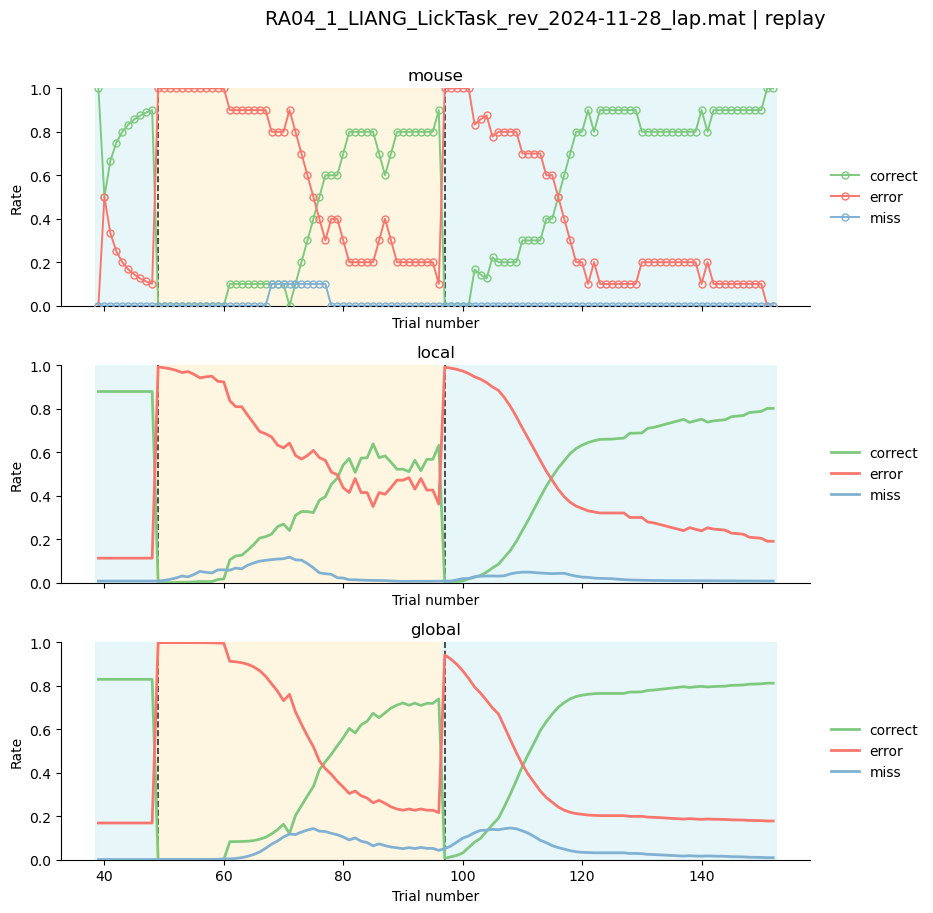

In [10]:
fig, axes, perf_tables = plot_mouse_local_global_performance(
    details["decision_df"],
    local_fit=details["local_fit"],
    global_fit=details["global_fit"],
    config=config,
    plot_mode="replay",
    seed=0,
    title=Path(file_path).name,
)

plt.show()

In [11]:
input_folder = "../../data/PFC_NP/flexible_shift/Behavior only"

all_comparisons, errors_df, all_details = analyze_mat_folder(
    input_folder,
    config=config,
)

display(all_comparisons)

if not errors_df.empty:
    display(errors_df)

[File selection] before=31, after=31, mouse_id_filter=()
[OK] RC03_L-PFC-1_POSI-PATT_LickTask_rev_2025-05-30_lap | best=local_q_two_alpha_q_sigmoid_shared | BIC=166.348 | NLL/decision=0.2203 | p_base=0.0000
[OK] RC02_L-PFC-1_PATT-POSI_LickTask_rev_2025-06-11_lap | best=global_rule_q_softmax_two_alpha_shared | BIC=142.140 | NLL/decision=0.1477 | p_base=0.0036
[OK] RA04_1_LIANG_LickTask_rev_2024-12-01_lap | best=global_rule_q_softmax_two_alpha_shared | BIC=200.366 | NLL/decision=0.1850 | p_base=0.0208
[OK] LL01_1_LIANG_LickTask_rev_2024-12-17_lap | best=global_rule_q_softmax_two_alpha_shared | BIC=214.198 | NLL/decision=0.1508 | p_base=0.0180
[OK] RA04_1_LIANG_LickTask_rev_2024-11-28_lap | best=global_rule_q_softmax_two_alpha_shared | BIC=242.078 | NLL/decision=0.2087 | p_base=0.0452
[OK] LL01_1_LIANG_LickTask_rev_2024-12-11_lap | best=global_rule_q_softmax_two_alpha_shared | BIC=251.831 | NLL/decision=0.2041 | p_base=0.0329
[OK] RA04_1_LIANG_LickTask_rev_2024-12-03_lap | best=local_q_tw

,session_id,file_name,model,model_kind,n_params,n_decisions,n_diagnostic_decisions,p_base_mean,p_explore_mean,alpha_up_mean,...,global_beta_mean,theta_mean,p_high,nll,nll_per_decision,diagnostic_nll,diagnostic_nll_per_decision,aic,bic,optimization_success
0,LL01_1_LIANG_LickTask_rev_2024-12-02_lap,LL01_1_LIANG_LickTask_rev_2024-12-02_lap.mat,global_rule_q_softmax_two_alpha_shared,global,4,525,178,0.039764,NaN,0.002096,...,7.801861,NaN,0.999,103.717367,0.197557,55.244253,0.310361,215.434734,232.488327,True
1,LL01_1_LIANG_LickTask_rev_2024-12-02_lap,LL01_1_LIANG_LickTask_rev_2024-12-02_lap.mat,local_q_two_alpha_q_sigmoid_shared,local,4,525,178,0.024845,0.0,0.314708,...,NaN,NaN,0.999,107.941418,0.205603,59.357935,0.333472,223.882837,240.936430,True
2,LL01_1_LIANG_LickTask_rev_2024-12-11_lap,LL01_1_LIANG_LickTask_rev_2024-12-11_lap.mat,global_rule_q_softmax_two_alpha_shared,global,4,555,208,0.032945,NaN,0.000001,...,2.587840,NaN,0.999,113.277454,0.204104,71.465727,0.343585,234.554907,251.830779,True
3,LL01_1_LIANG_LickTask_rev_2024-12-11_lap,LL01_1_LIANG_LickTask_rev_2024-12-11_lap.mat,local_q_two_alpha_q_sigmoid_shared,local,4,555,208,0.000010,0.0,1.000000,...,NaN,NaN,0.999,136.294160,0.245575,90.940601,0.437214,280.588320,297.864192,True
4,LL01_1_LIANG_LickTask_rev_2024-12-17_lap,LL01_1_LIANG_LickTask_rev_2024-12-17_lap.mat,global_rule_q_softmax_two_alpha_shared,global,4,625,244,0.017971,NaN,1.000000,...,2.703037,NaN,0.999,94.223579,0.150758,63.360569,0.259674,196.447157,214.198164,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,RG02_1_L_LickTask_rev_2026-04-29_lap,RG02_1_L_LickTask_rev_2026-04-29_lap.mat,global_rule_q_softmax_two_alpha_shared,global,4,860,210,0.063518,NaN,0.000001,...,1.491222,NaN,0.999,237.556066,0.276228,118.505425,0.564312,483.112132,502.139862,True
58,RG02_1_L_LickTask_rev_2026-05-05_lap,RG02_1_L_LickTask_rev_2026-05-05_lap.mat,global_rule_q_softmax_two_alpha_shared,global,4,760,182,0.024758,NaN,0.000001,...,1.642317,NaN,0.999,151.833759,0.199781,94.729294,0.520491,311.667518,330.200792,True
59,RG02_1_L_LickTask_rev_2026-05-05_lap,RG02_1_L_LickTask_rev_2026-05-05_lap.mat,local_q_two_alpha_q_sigmoid_shared,local,4,760,182,0.000010,0.0,0.437885,...,NaN,NaN,0.999,181.422740,0.238714,116.250529,0.638739,370.845479,389.378753,True
60,RG02_L-PFC-HPC-1_PATT-POSI-PATT_LickTask_rev_2...,RG02_L-PFC-HPC-1_PATT-POSI-PATT_LickTask_rev_2...,local_q_two_alpha_q_sigmoid_shared,local,4,550,132,0.000010,0.0,0.469042,...,NaN,NaN,0.999,132.389766,0.240709,58.105814,0.440196,272.779532,290.019205,True


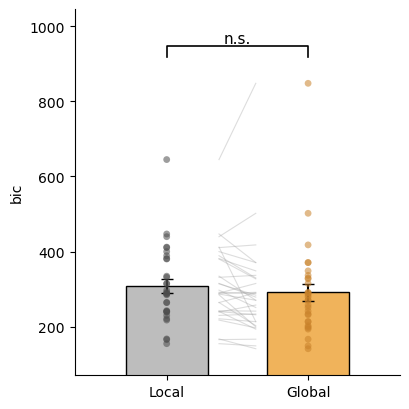

,session_id,file_name,local_model,local,global_model,global,local_minus_global
0,LL01_1_LIANG_LickTask_rev_2024-12-02_lap,LL01_1_LIANG_LickTask_rev_2024-12-02_lap.mat,local_q_two_alpha_q_sigmoid_shared,240.936430,global_rule_q_softmax_two_alpha_shared,232.488327,8.448103
1,LL01_1_LIANG_LickTask_rev_2024-12-11_lap,LL01_1_LIANG_LickTask_rev_2024-12-11_lap.mat,local_q_two_alpha_q_sigmoid_shared,297.864192,global_rule_q_softmax_two_alpha_shared,251.830779,46.033413
2,LL01_1_LIANG_LickTask_rev_2024-12-17_lap,LL01_1_LIANG_LickTask_rev_2024-12-17_lap.mat,local_q_two_alpha_q_sigmoid_shared,412.251629,global_rule_q_softmax_two_alpha_shared,214.198164,198.053465
3,LL01_1_LIANG_LickTask_rev_2024-12-18_lap,LL01_1_LIANG_LickTask_rev_2024-12-18_lap.mat,local_q_two_alpha_q_sigmoid_shared,287.461498,global_rule_q_softmax_two_alpha_shared,271.075106,16.386392
4,RA02_1_LIANG_LickTask_rev_2024-11-04_lap,RA02_1_LIANG_LickTask_rev_2024-11-04_lap.mat,local_q_two_alpha_q_sigmoid_shared,380.636018,global_rule_q_softmax_two_alpha_shared,327.897521,52.738497
5,RA04_1_LIANG_LickTask_rev_2024-11-28_lap,RA04_1_LIANG_LickTask_rev_2024-11-28_lap.mat,local_q_two_alpha_q_sigmoid_shared,243.268618,global_rule_q_softmax_two_alpha_shared,242.078487,1.190131
6,RA04_1_LIANG_LickTask_rev_2024-11-29_lap,RA04_1_LIANG_LickTask_rev_2024-11-29_lap.mat,local_q_two_alpha_q_sigmoid_shared,241.375389,global_rule_q_softmax_two_alpha_shared,194.193115,47.182273
7,RA04_1_LIANG_LickTask_rev_2024-12-01_lap,RA04_1_LIANG_LickTask_rev_2024-12-01_lap.mat,local_q_two_alpha_q_sigmoid_shared,285.401240,global_rule_q_softmax_two_alpha_shared,200.365848,85.035392
8,RA04_1_LIANG_LickTask_rev_2024-12-03_lap,RA04_1_LIANG_LickTask_rev_2024-12-03_lap.mat,local_q_two_alpha_q_sigmoid_shared,239.614925,global_rule_q_softmax_two_alpha_shared,258.218752,-18.603827
9,RA04_1_LIANG_LickTask_rev_2024-12-05_lap,RA04_1_LIANG_LickTask_rev_2024-12-05_lap.mat,local_q_two_alpha_q_sigmoid_shared,332.014035,global_rule_q_softmax_two_alpha_shared,337.245644,-5.231609


{'n': 31, 'mean_difference': 17.796507473838663, 'median_difference': 16.386391825470582, 'p_value': 0.11971880281197188}


In [12]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))

ax, test_result, paired_bic = plot_paired_local_global(
    all_comparisons,
    metric="bic",
    ylabel="bic",
    seed=0,
    ax=ax,
)

plt.show()

display(paired_bic)
print(test_result)